In [1]:
import xarray as xr
import matplotlib.pyplot as plt 
import seaborn as sns
import cartopy.crs as ccrs
import seaborn.objects as so
import numpy as np
from dask.distributed import LocalCluster, Client
import flox.xarray
import xesmf as xe
from affine import Affine

from tqdm.notebook import tqdm
import scipy
import dask.bag as db
from pyproj import Proj, Transformer, CRS
import geopandas as gpd
from rasterio import features
from shapely.geometry import shape, Polygon

import pandas as pd
plt.style.use('robin')
from matplotlib.colors import LogNorm, Normalize
proj = ccrs.NorthPolarStereo(0,70)
import dask.bag as db

def sigmoid(x):
    return 1/(1+np.exp(-x))
def logit(x):
    return np.log(x/(1-x)) 

In [2]:
cluster = LocalCluster(n_workers=4, memory_limit='12GiB')
client = Client(cluster)
client

/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 40869 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:40869/status,
Dashboard: http://127.0.0.1:40869/status,Workers: 4
Total threads: 64,Total memory: 48.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:40455,Workers: 0
Dashboard: http://127.0.0.1:40869/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:36865,Total threads: 16
Dashboard: http://127.0.0.1:35477/status,Memory: 12.00 GiB
Nanny: tcp://127.0.0.1:43193,


# Load experiments results

In [3]:
# run_id = '3w874ud3'
# run_id = '0obl1joe'
# run_id = '75kakckt'
# run_id = 'wisxbydg'
# run_id = 'bd4apy6o'
run_id ='ima3ba04'
# run_id = 'cx6e235z'
# ds_attrs = xr.open_dataset(f'/Data/gfi/users/rogui7909/data/NN_outputs/attributions/newproj/{run_id}_attributions.nc', chunks = dict(time_of_event=20)).load()
ds_attrs = xr.open_dataset(f'/Data/gfi/users/rogui7909/data/NN_outputs/attributions/newproj/{run_id}_ALL_attributions_v3.nc', chunks = dict(time_of_event=20)).load().transpose('y','x',...)

# ds_moran = xr.open_dataset(f'/Data/gfi/users/rogui7909/data/NN_outputs/attributions/newproj/{run_id}_moranI_lrp_normed_v2.nc') 
# ds_attrs['moran_I'] = ds_moran.Moran_I

grid = ds_attrs.isel(time_of_event=0, timestep_past=0, var_name=0).attributions_lrp
# normalize = logit(.9)/128/128
lrp_normed = ds_attrs.attributions_lrp.sum('var_name')#/normalize
lrp_normed = lrp_normed/lrp_normed.clip(0).sum(['x','y'])
ds_attrs['lrp_normed'] = lrp_normed

# ig_normed = ds_attrs.attributions_ig.sum('var_name')
# ig_normed = ig_normed/ig_normed.clip(0).sum(['x','y'])
# cycs = cycs.query("msl<100000")
ds_attrs

<xarray.Dataset> Size: 3GB
Dimensions:           (time_of_event: 840, y: 128, x: 128, timestep_past: 7,
                       var_name: 3)
Coordinates:
    quantile          float64 8B 0.95
  * x                 (x) float64 1kB -1e+07 -9.882e+06 ... 4.882e+06 5e+06
  * y                 (y) float64 1kB -1e+07 -9.882e+06 ... 4.882e+06 5e+06
  * var_name          (var_name) <U4 48B 'u850' 'v850' 'msl'
    lat               (y, x) float32 66kB -7.882 -7.545 -7.207 ... 31.09 30.5
    lon               (y, x) float32 66kB -45.0 -44.66 -44.32 ... 135.7 135.0
  * timestep_past     (timestep_past) int64 56B -6 -5 -4 -3 -2 -1 0
  * time_of_event     (time_of_event) datetime64[ns] 7kB 1979-01-07 ... 2024-...
Data variables:
    rain              (time_of_event) float64 7kB 30.89 37.58 ... 31.53 28.58
    targets           (time_of_event) float64 7kB 1.0 1.0 1.0 ... 1.0 1.0 1.0
    attributions_ig   (y, x, time_of_event, timestep_past, var_name) float32 1GB ...
    attributions_lrp  (y, x, time_of_event, timestep_past, var_name) float32 1GB ...
    predictions       (time_of_event, timestep_past) float32 24kB 1.192 ... 4...
    lrp_normed        (y, x, time_of_event, timestep_past) float32 385MB 0.0 ...

## Compute aggregation with Moran's I


In [4]:
from esda.moran import Moran
from libpysal.weights import KNN, DistanceBand


times = ds_attrs.time_of_event.sel(time_of_event=slice('1979', '2024')).values

data = ds_attrs.sel(time_of_event='2016-08-09').sel(timestep_past=0).lrp_normed

X = data.to_dataframe().lrp_normed.reset_index().x.values
Y = data.to_dataframe().lrp_normed.reset_index().y.values
coords = np.column_stack([X, Y])
w = KNN.from_array(coords, k=4)  # or k=8

results = []

for time_of_event in tqdm(times):
    for timestep_past in range(-6,1):
        data_ = ds_attrs.sel(time_of_event=time_of_event).sel(timestep_past=timestep_past).lrp_normed
        numbers = data_.values.flatten()
        mi = Moran(numbers,w)
        results.append([time_of_event, timestep_past, mi.I, mi.p_sim])


ds = pd.DataFrame(results, columns = ['time_of_event','timestep_past','Moran_I','p_value']).set_index(['time_of_event','timestep_past']).to_xarray()
ds.to_netcdf(f'/Data/gfi/users/rogui7909/data/NN_outputs/attributions/newproj/{run_id}_moranI_lrp_normed_v2.nc')

  0%|          | 0/840 [00:00<?, ?it/s]

# Cyclones stuff

## Load cyclone data

In [ ]:
all_df_dailys = []
import glob
files = glob.glob('/Data/gfi/share/Reanalyses/ERA-5/detected_features/cyclone_tracks_melbourne/*.pos.nc')
files = [f for f in files if f.endswith('.nc')]
proj_stereo = CRS(f"+proj=stere +lat_0=90 +lat_ts=70 +lon_0=0 +x_0=0 +y_0=0 +ellps=WGS84 +units=m")
transformer = Transformer.from_crs("EPSG:4326", proj_stereo, always_xy=True)
for file in tqdm(files):
    with xr.open_dataset(file) as ds:
        df_ = ds[['track_id', 'lon','lat','msl','date']].to_dataframe()
        df_['date'] = pd.to_datetime(df_.date.dt.date)
        df_daily = df_.groupby(['date','track_id']).agg({'msl':'min','lon':'mean','lat':'mean'}).reset_index()   
        x,y = transformer.transform(df_daily['lon'].values, df_daily['lat'].values)
        df_daily['x'] = x
        df_daily['y'] = y
        all_df_dailys.append(df_daily)
        del df_
daily_cycs = pd.concat(all_df_dailys)
daily_cycs = daily_cycs.loc[(daily_cycs.x > -1e7)&(daily_cycs.x < .5e7)&(daily_cycs.y > -1e7)&(daily_cycs.y < .5e7)]
daily_cycs = daily_cycs.set_index('date').sort_index()
daily_cycs['track_id']=daily_cycs['track_id'].astype(int)#.astype(float)
daily_cycs['key'] = daily_cycs.index.strftime("%Y-%m-%d") + ' '+daily_cycs.track_id.astype(str)


cyclones_gdf = gpd.GeoDataFrame(
    daily_cycs.reset_index(),
    geometry=gpd.points_from_xy(daily_cycs["x"], daily_cycs["y"]),
    crs=proj  # adjust if your cyclones are in another CRS
).set_index('date')




  0%|          | 0/552 [00:00<?, ?it/s]

## Define processing functions

In [ ]:
# def segments_from_attribution_grid(data, abs_threshold = 1, rolling=3):
#     data_rolling = data.rolling(x=rolling,y=rolling,center=True).mean().fillna(0)
#     data_rolling = data_rolling.where(np.abs(data_rolling)>abs_threshold,0)
#     img = data_rolling.values
#     img = img#/img.max()
#     segments_fz, num_features = scipy.ndimage.label(img, structure=[[1,1,1],[1,1,1],[1,1,1],])
#     segments = xr.DataArray(segments_fz, dims=data.dims, coords=data.coords)
#     attribution_per_segment = data.groupby(segments).sum().to_series().rename('attributions')
#     return segments, attribution_per_segment



# def get_gdf_from_segment_grid(segments):
#     x = segments.x.values
#     y = segments.y.values
#     labels = segments.values
#     dx = float(np.mean(np.diff(x))) 
#     dy = float(np.mean(np.diff(y))) 
#     x0 = x.min() - dx / 2.0
#     y0 = y.min() - dy / 2.0  
#     transform = Affine.translation(x0, y0) * Affine.scale(dx, dy)
#     geoms = []
#     vals = []
#     for geom, value in features.shapes(labels, transform=transform):
#         if value == 0:
#             continue
#         geoms.append(shape(geom))
#         vals.append(value)
#     gdf_segments = gpd.GeoDataFrame(
#         {"label": vals},
#         geometry=geoms,
#         crs="EPSG:3413"   # or "EPSG:3995" or your custom proj string
#     )
#     gdf_segments= gdf_segments.set_index('label') 
#     gdf_segments=gdf_segments.reset_index().dissolve(by='label')
#     return gdf_segments

# def get_segments_gdf_for_day(time_of_event, timestep_past, segments_kwargs=dict()):
#     data = ds_attrs.sel(time_of_event=time_of_event,timestep_past=timestep_past).lrp_normed
#     data = data.rio.write_crs(proj) 
#     segments, attribution_per_segment = segments_from_attribution_grid(data, **segments_kwargs)
#     gdf_segments = get_gdf_from_segment_grid(segments)
#     gdf_segments['attributions'] = attribution_per_segment
#     gdf_segments = gdf_segments.loc[gdf_segments.geometry.notnull()]
#     return segments, gdf_segments, data

# def get_cyclones_for_day(time_of_event, timestep_past):
#     time = pd.to_datetime(time_of_event) + pd.Timedelta(f'{timestep_past}D')
#     cyclones_gdf_day = cyclones_gdf.loc[time.strftime("%Y-%m-%d")]
#     return cyclones_gdf_day.set_index('track_id')

# def get_intersection(gdf_segments, cyclones_gdf_day, buffer=500_000):
#     intersects = cyclones_gdf_day.geometry.buffer(buffer).apply(lambda g: gdf_segments.intersection(g).loc[gdf_segments.intersects(g)]).dropna(how='all')
#     intersects = intersects.stack().reset_index()
#     intersects.columns = ['track_id','segment_label','geometry']
#     intersects = gpd.GeoDataFrame(intersects, geometry='geometry', crs=gdf_segments.crs)
#     return intersects

# def get_intersection_voronoi(gdf_segments, cyclones_gdf_day, buffer=500_000):
#     limit = Polygon([(-1e7, -1e7), (-1e7, 1e7), (1e7, 1e7), (1e7, -1e7)])
#     all_voronoi_intersection = []
#     n_patches=gdf_segments.index.size
#     # print(n_patches)
#     for k in range(n_patches):
#         patch = gdf_segments.iloc[k]
#         patch_label = gdf_segments.index[k]
#         intersection_ = cyclones_gdf_day.geometry.buffer(buffer).intersection(patch.geometry)
#         intersection_ = intersection_.loc[intersection_.area>0]
#         intersection_
#         if len(intersection_.index)==0:
#             all_voronoi_intersection.append(pd.DataFrame(dict(track_id=['No cyclone'],segment_label=[patch_label],geometry=[patch.geometry])))
#         elif len(intersection_.index)==1:
#             all_voronoi_intersection.append(pd.DataFrame(dict(track_id=[intersection_.index[0]],segment_label=[patch_label],geometry=[patch.geometry])))
#         else:
#             voronoi = cyclones_gdf_day.loc[intersection_.index].geometry.voronoi_polygons(extend_to=limit)
#             voronoi.index = intersection_.index
#             voronoi_intersection = voronoi.intersection(patch.geometry).rename('geometry').reset_index()
#             voronoi_intersection['segment_label'] = gdf_segments.index[k]+voronoi_intersection.index/10
#             all_voronoi_intersection.append(voronoi_intersection)
#     if n_patches>0:
#         voronoi_out = pd.concat(all_voronoi_intersection)
#         voronoi_out = gpd.GeoDataFrame(voronoi_out, geometry='geometry', crs=gdf_segments.crs)
#     else:
#         voronoi_out = gpd.GeoDataFrame(columns=['track_id','segment_label','geometry'], geometry='geometry', crs=gdf_segments.crs)
#     return voronoi_out

# def get_attributions(data,voronoi_intersections ):
#     data = data.rio.write_crs(proj) 
#     mask = xr.full_like(data, np.nan)

#     for i, poly in enumerate(voronoi_intersections.geometry):
#         clipped = data.rio.clip([poly], drop=False)
#         mask = mask.where(clipped.isnull(), i + 1)
#     mask = mask.rename("region")
#     attributions = (data.groupby(mask).sum()).to_series()
#     attributions = attributions.reindex(np.arange(1, voronoi_intersections.shape[0]+1)).fillna(0)
#     attributions.index = voronoi_intersections.segment_label    
#     return attributions

# def attribution_segments(gdf_segments, cyclones_gdf_day, data):
#     if gdf_segments.index.size==0:
#         return None
#     intersects500= get_intersection_voronoi(gdf_segments, cyclones_gdf_day, buffer=500_000)
#     intersects500['area'] = intersects500.geometry.area
#     intersects500 = intersects500.loc[intersects500.area>0]
#     attributions = get_attributions(data,intersects500 )
#     intersects500 = intersects500.set_index('segment_label')
#     intersects500['attributions'] = attributions

#     intersects500 = intersects500.loc[intersects500.attributions!=0]
#     # gdf_segments['cyclones'] = intersects500.set_index('track_id').groupby('segment_label').area.idxmax()
#     return intersects500.reset_index()



In [ ]:
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from scipy import ndimage as ndi


def segments_from_attribution_grid_watershed(time_of_event, timestep_past, abs_threshold = 0.001, rolling=5):
    data = ds_attrs.sel(time_of_event=time_of_event,timestep_past=timestep_past).lrp_normed
    data = data.rio.write_crs(proj) 
    img = data.rolling(x=rolling, y=rolling, center=True).mean()
    img_filter = img.where(np.abs(img)>abs_threshold).fillna(0)
    coords = peak_local_max(img_filter.values)
    mask = np.zeros(img.shape, dtype=bool)
    mask[tuple(coords.T)] = True
    markers, _ = ndi.label(mask)
    labels = watershed(-np.abs(img), markers, mask=img)
    patch_labels = xr.DataArray(labels, dims=img.dims, coords=img.coords)
    # plt.imshow(labels)
    # plt.imshow(img.where(np.abs(img)>abs_threshold))
    patch_labels = patch_labels.where(np.abs(img)>abs_threshold)
    attributions = img.groupby(patch_labels).sum()

    gdf_patches = get_gdf_from_segment_grid(patch_labels)
    gdf_patches['patch_attributions'] = attributions.values
    gdf_patches['patch_area'] = gdf_patches.geometry.area/1_000_000
    gdf_patches['patch_pixel_count'] = np.round(gdf_patches.patch_area/117000/117000)
    X_values = [img.x[coords[k,1]].values for k in range(gdf_patches.index.size)]
    Y_values = [img.y[coords[k,0]].values for k in range(gdf_patches.index.size)]
    gdf_patches['location_local_max'] = gpd.points_from_xy(X_values, Y_values, crs=proj)
    return gdf_patches, data




def get_cyclones_for_day(time_of_event, timestep_past):
    time = pd.to_datetime(time_of_event) + pd.Timedelta(f'{timestep_past}D')
    cyclones_gdf_day = cyclones_gdf.loc[time.strftime("%Y-%m-%d")]
    return cyclones_gdf_day.set_index('track_id')

def get_top_cycs_area_overlap(series):
        geom = gpd.GeoDataFrame(geometry=series)
        if np.isnan(geom.area.max()):
            return np.nan
        else:
            return geom.area.idxmax()

def get_best_cycs_per_distance(series):
    cycs_available_index = series.dropna().index
    if len(cycs_available_index) == 0:
        return np.nan
    cycs_available = cyclones_gdf_day.loc[cycs_available_index].geometry
    dist = cycs_available.distance(gdf_patches.loc[series.name].location_local_max)
    return dist.idxmax()

def attribution_patches_to_cyclones(gdf_patches,cyclones_gdf_day, buffer=500_000):
    geom = gdf_patches.geometry.apply(lambda g: cyclones_gdf_day.buffer(buffer).intersection(g).loc[cyclones_gdf_day.buffer(buffer).intersects(g)])
    track_id = geom.apply(get_best_cycs_per_distance, axis=1)
    
    gdf_patches['cyclone_track_id'] = track_id.values
    return gdf_patches



gdf_patches, data = segments_from_attribution_grid_watershed('2016-08-09',-1)
cyclones_gdf_day = get_cyclones_for_day(time_of_event, timestep_past)
gdf_patches = attribution_patches_to_cyclones(gdf_patches, cyclones_gdf_day)

# gdf_patches.groupby(#.dissolve()#.plot(cmap='viridis')
# data.plot()
gdf_patches

,geometry,patch_attributions,patch_area,patch_pixel_count,location_local_max,cyclone_track_id
label,,,,,,
1.0,"POLYGON ((-19685.039 -3917322.835, -19685.039 ...",0.245848,1.436853e+12,105.0,POINT (39370.079 -3149606.299),955154
2.0,"POLYGON ((452755.906 -3917322.835, 452755.906 ...",0.087048,4.882510e+11,36.0,POINT (511811.024 -3149606.299),955154
3.0,"POLYGON ((688976.378 -3917322.835, 688976.378 ...",0.125309,8.509517e+11,62.0,POINT (748031.496 -3149606.299),955306


In [458]:
df_.index

Index([1.0, 2.0, 3.0, 1.0, 2.0, 3.0, 1.0, 2.0, 3.0, 1.0,
       ...
       3.0, 1.0, 2.0, 3.0, 1.0, 2.0, 3.0, 1.0, 2.0, 3.0],
      dtype='float64', name='label', length=420)

In [ ]:
times = ds_attrs.time_of_event.sel(time_of_event=slice(None, '2024')).values
all_gdf_segments = []
for time_of_event in tqdm(times):
    for timestep_past in range(-6,1):
        gdf_patches, data = segments_from_attribution_grid_watershed('2016-08-09',-1)
        if gdf_patches.index.size>0:
            cyclones_gdf_day = get_cyclones_for_day(time_of_event, timestep_past)
            gdf_patches = attribution_patches_to_cyclones(gdf_patches, cyclones_gdf_day)
            gdf_patches['time_of_event'] = time_of_event
            gdf_patches['timestep_past'] = timestep_past            
            all_gdf_segments.append(gdf_patches)
            
df_ = pd.concat(all_gdf_segments)
df_['is_cyclone'] = df_.cyclone_track_id.notnull()
df_['date'] = df_.time_of_event + pd.Timedelta('1D')*df_.timestep_past
categories = np.array(['                     ' for k in df_.index])
categories[((df_.patch_area<0.1e7)).values] = 'small blob'
categories[((np.abs(df_.patch_attributions)<.05)&(df_.patch_area>0.1e7)).values] = 'large neutral'
categories[((df_.patch_attributions<-.05)&(df_.patch_area>0.1e7)).values] = 'large negative'
categories[((df_.patch_attributions>.05)&(df_.patch_area>0.1e7)).values] = 'large positive'
df_['category'] = categories

key = (df_.reset_index().date.dt.strftime("%Y-%m-%d") + ' '+df_.reset_index().cyclone_track_id.fillna(0).astype(int).astype(str)).values
key[df_.cyclone_track_id.isnull()] = '1979-01-02 0'
df_['key'] = key
df_ = df_.set_index(key)
daily_cycs_for_patches = daily_cycs.reset_index().set_index('key').loc[df_.key]
df_[['cyclone_msl','cyclone_lon','cyclone_lat','cyclone_x','cyclone_y']] = daily_cycs_for_patches[['msl','lon','lat','x','y']].values

df_ = df_.reset_index().rename(columns=dict( date='cyclone_date',segment_size='blob_area', attributions='blob_attributions'))
df_.loc[df_.cyclone_track_id=='No cyclone', ['key','cyclone_msl','cyclone_lon','cyclone_lat','cyclone_x','cyclone_y']] = np.nan
df_['is_cyclone'] = df_.cyclone_track_id.notnull()

df_.drop('location_local_max', axis=1).to_file(f'/Data/gfi/users/rogui7909/data/NN_outputs/attributions/newproj/{run_id}_cyclones_data_watershed.geojson', driver='GeoJSON')
# 
# df_ = df_.rename(columns=dict(track_id='cyclones'))

  0%|          | 0/840 [00:00<?, ?it/s]

ValueError: GeoDataFrame contains multiple geometry columns but GeoDataFrame.to_file supports only a single geometry column. Use a GeoDataFrame.to_parquet or GeoDataFrame.to_feather, drop additional geometry columns or convert them to a supported format like a well-known text (WKT) using `GeoSeries.to_wkt()`.

In [474]:
df_.drop('location_local_max', axis=1).to_file(f'/Data/gfi/users/rogui7909/data/NN_outputs/attributions/newproj/{run_id}_cyclones_data_watershed.geojson', driver='GeoJSON')

In [469]:
df_

,index,geometry,patch_attributions,patch_area,patch_pixel_count,location_local_max,cyclone_track_id,time_of_event,timestep_past,is_cyclone,cyclone_date,category,key,cyclone_msl,cyclone_lon,cyclone_lat,cyclone_x,cyclone_y
0,1979-01-01 9,"POLYGON ((-19685.039 -3917322.835, -19685.039 ...",0.245848,1.436853e+12,105.0,POINT (39370.079 -3149606.299),9.0,1979-01-07,-6,True,1979-01-01,large positive,1979-01-01 9,100280.337114,-16.353258,66.703640,-7.201089e+05,-2.454110e+06
1,1979-01-02 0,"POLYGON ((452755.906 -3917322.835, 452755.906 ...",0.087048,4.882510e+11,36.0,POINT (511811.024 -3149606.299),NaN,1979-01-07,-6,False,1979-01-01,large positive,1979-01-02 0,100748.992025,-63.887996,50.383825,-4.008538e+06,-1.964804e+06
2,1979-01-02 0,"POLYGON ((688976.378 -3917322.835, 688976.378 ...",0.125309,8.509517e+11,62.0,POINT (748031.496 -3149606.299),NaN,1979-01-07,-6,False,1979-01-01,large positive,1979-01-02 0,100748.992025,-63.887996,50.383825,-4.008538e+06,-1.964804e+06
3,1979-01-02 12,"POLYGON ((-19685.039 -3917322.835, -19685.039 ...",0.245848,1.436853e+12,105.0,POINT (39370.079 -3149606.299),12.0,1979-01-07,-5,True,1979-01-02,large positive,1979-01-02 12,101302.174964,3.542400,53.119759,2.553956e+05,-4.125575e+06
4,1979-01-02 12,"POLYGON ((452755.906 -3917322.835, 452755.906 ...",0.087048,4.882510e+11,36.0,POINT (511811.024 -3149606.299),12.0,1979-01-07,-5,True,1979-01-02,large positive,1979-01-02 12,101302.174964,3.542400,53.119759,2.553956e+05,-4.125575e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
415,1979-01-02 0,"POLYGON ((452755.906 -3917322.835, 452755.906 ...",0.087048,4.882510e+11,36.0,POINT (511811.024 -3149606.299),NaN,1980-09-02,-1,False,1980-09-01,large positive,1979-01-02 0,100748.992025,-63.887996,50.383825,-4.008538e+06,-1.964804e+06
416,1979-01-02 0,"POLYGON ((688976.378 -3917322.835, 688976.378 ...",0.125309,8.509517e+11,62.0,POINT (748031.496 -3149606.299),NaN,1980-09-02,-1,False,1980-09-01,large positive,1979-01-02 0,100748.992025,-63.887996,50.383825,-4.008538e+06,-1.964804e+06
417,1980-09-02 34896,"POLYGON ((-19685.039 -3917322.835, -19685.039 ...",0.245848,1.436853e+12,105.0,POINT (39370.079 -3149606.299),34896.0,1980-09-02,0,True,1980-09-02,large positive,1980-09-02 34896,99486.673887,-20.670456,65.535260,-9.494036e+05,-2.516447e+06
418,1980-09-02 35188,"POLYGON ((452755.906 -3917322.835, 452755.906 ...",0.087048,4.882510e+11,36.0,POINT (511811.024 -3149606.299),35188.0,1980-09-02,0,True,1980-09-02,large positive,1980-09-02 35188,99702.227924,5.266135,65.995778,2.420742e+05,-2.626357e+06


In [450]:
df_

,geometry,patch_attributions,patch_area,patch_pixel_count,location_local_max,cyclone_track_id,time_of_event,timestep_past,is_cyclone,date
label,,,,,,,,,,
1.0,"POLYGON ((-19685.039 -3917322.835, -19685.039 ...",0.245848,1.436853e+12,105.0,POINT (39370.079 -3149606.299),9.0,1979-01-07,-6,True,1979-01-01
2.0,"POLYGON ((452755.906 -3917322.835, 452755.906 ...",0.087048,4.882510e+11,36.0,POINT (511811.024 -3149606.299),NaN,1979-01-07,-6,False,1979-01-01
3.0,"POLYGON ((688976.378 -3917322.835, 688976.378 ...",0.125309,8.509517e+11,62.0,POINT (748031.496 -3149606.299),NaN,1979-01-07,-6,False,1979-01-01
1.0,"POLYGON ((-19685.039 -3917322.835, -19685.039 ...",0.245848,1.436853e+12,105.0,POINT (39370.079 -3149606.299),12.0,1979-01-07,-5,True,1979-01-02
2.0,"POLYGON ((452755.906 -3917322.835, 452755.906 ...",0.087048,4.882510e+11,36.0,POINT (511811.024 -3149606.299),12.0,1979-01-07,-5,True,1979-01-02
...,...,...,...,...,...,...,...,...,...,...
2.0,"POLYGON ((452755.906 -3917322.835, 452755.906 ...",0.087048,4.882510e+11,36.0,POINT (511811.024 -3149606.299),NaN,1980-09-02,-1,False,1980-09-01
3.0,"POLYGON ((688976.378 -3917322.835, 688976.378 ...",0.125309,8.509517e+11,62.0,POINT (748031.496 -3149606.299),NaN,1980-09-02,-1,False,1980-09-01
1.0,"POLYGON ((-19685.039 -3917322.835, -19685.039 ...",0.245848,1.436853e+12,105.0,POINT (39370.079 -3149606.299),34896.0,1980-09-02,0,True,1980-09-02


In [ ]:
# df_['is_cyclone'] = df_.cyclone_track_id.notnull()
df_['date'] = df_.time_of_event + pd.Timedelta('1D')*df_.timestep_past
categories = np.array(['                     ' for k in df_.index])
categories[((df_.segment_size<0.1e7)).values] = 'small blob'
categories[((np.abs(df_.attributions)<.05)&(df_.segment_size>0.1e7)).values] = 'large neutral'
categories[((df_.attributions<-.05)&(df_.segment_size>0.1e7)).values] = 'large negative'
categories[((df_.attributions>.05)&(df_.segment_size>0.1e7)).values] = 'large positive'
df_['category'] = categories


AttributeError: 'GeoDataFrame' object has no attribute 'time_of_event'

In [448]:
df_

,geometry,patch_attributions,patch_area,patch_pixel_count,location_local_max,cyclone_track_id,is_cyclone
label,,,,,,,
1.0,"POLYGON ((-19685.039 -3917322.835, -19685.039 ...",0.245848,1.436853e+12,105.0,POINT (39370.079 -3149606.299),9.0,True
2.0,"POLYGON ((452755.906 -3917322.835, 452755.906 ...",0.087048,4.882510e+11,36.0,POINT (511811.024 -3149606.299),NaN,False
3.0,"POLYGON ((688976.378 -3917322.835, 688976.378 ...",0.125309,8.509517e+11,62.0,POINT (748031.496 -3149606.299),NaN,False
1.0,"POLYGON ((-19685.039 -3917322.835, -19685.039 ...",0.245848,1.436853e+12,105.0,POINT (39370.079 -3149606.299),12.0,True
2.0,"POLYGON ((452755.906 -3917322.835, 452755.906 ...",0.087048,4.882510e+11,36.0,POINT (511811.024 -3149606.299),12.0,True
...,...,...,...,...,...,...,...
2.0,"POLYGON ((452755.906 -3917322.835, 452755.906 ...",0.087048,4.882510e+11,36.0,POINT (511811.024 -3149606.299),955944.0,True
3.0,"POLYGON ((688976.378 -3917322.835, 688976.378 ...",0.125309,8.509517e+11,62.0,POINT (748031.496 -3149606.299),NaN,False
1.0,"POLYGON ((-19685.039 -3917322.835, -19685.039 ...",0.245848,1.436853e+12,105.0,POINT (39370.079 -3149606.299),955944.0,True


In [445]:
df_

,geometry,patch_attributions,patch_area,patch_pixel_count,location_local_max,cyclone_track_id
label,,,,,,
1.0,"POLYGON ((-19685.039 -3917322.835, -19685.039 ...",0.245848,1.436853e+12,105.0,POINT (39370.079 -3149606.299),9.0
2.0,"POLYGON ((452755.906 -3917322.835, 452755.906 ...",0.087048,4.882510e+11,36.0,POINT (511811.024 -3149606.299),NaN
3.0,"POLYGON ((688976.378 -3917322.835, 688976.378 ...",0.125309,8.509517e+11,62.0,POINT (748031.496 -3149606.299),NaN
1.0,"POLYGON ((-19685.039 -3917322.835, -19685.039 ...",0.245848,1.436853e+12,105.0,POINT (39370.079 -3149606.299),12.0
2.0,"POLYGON ((452755.906 -3917322.835, 452755.906 ...",0.087048,4.882510e+11,36.0,POINT (511811.024 -3149606.299),12.0
...,...,...,...,...,...,...
2.0,"POLYGON ((452755.906 -3917322.835, 452755.906 ...",0.087048,4.882510e+11,36.0,POINT (511811.024 -3149606.299),118434.0
3.0,"POLYGON ((688976.378 -3917322.835, 688976.378 ...",0.125309,8.509517e+11,62.0,POINT (748031.496 -3149606.299),NaN
1.0,"POLYGON ((-19685.039 -3917322.835, -19685.039 ...",0.245848,1.436853e+12,105.0,POINT (39370.079 -3149606.299),118434.0


In [414]:
cycs_available

Index([955154], dtype='int64', name='track_id')

In [411]:
gdf_patches.loc[[series.name]].set_geometry('location_local_max').geometry

label
1.0    POINT (39370.079 -3149606.299)
Name: location_local_max, dtype: geometry

In [424]:
cycs_available

track_id
955154    POINT (375208.895 -2419758.872)
Name: geometry, dtype: geometry

In [ ]:
geom = gdf_patches.geometry.apply(lambda g: cyclones_gdf_day.buffer(buffer).intersection(g).loc[cyclones_gdf_day.buffer(buffer).intersects(g)])

cycs_available_index = series.dropna().index
    if len(cycs_available_index) == 0:
        return np.nan
    cycs_available = cyclones_gdf_day.loc[cycs_available_index].geometry
    dist = cycs_available.distance(gdf_patches.loc[series.name].location_local_max)
    return dist.idxmax()

def get_best_cycs_per_distance(series):
    cycs_available_index = series.dropna().index
    if len(cycs_available_index) == 0:
        return np.nan
    cycs_available = cyclones_gdf_day.loc[cycs_available_index].geometry
    dist = cycs_available.distance(gdf_patches.loc[series.name].location_local_max)
    return dist.idxmax()
# gdf_patches.set_geometry('location_local_max').loc[[series.name]].geometry.distance(cyclones_gdf_day.loc[cycs_available].geometry
# )
# geom.apply(get_best_cycs_per_distance)

label
1.0    None
2.0    None
3.0    None
dtype: object

,geometry,patch_attributions,patch_area,patch_pixel_count,location_local_max
label,,,,,
1.0,"POLYGON ((-19685.039 -3917322.835, -19685.039 ...",0.245848,1.436853e+12,105.0,POINT (39370.079 -3149606.299)
2.0,"POLYGON ((452755.906 -3917322.835, 452755.906 ...",0.087048,4.882510e+11,36.0,POINT (511811.024 -3149606.299)
3.0,"POLYGON ((688976.378 -3917322.835, 688976.378 ...",0.125309,8.509517e+11,62.0,POINT (748031.496 -3149606.299)


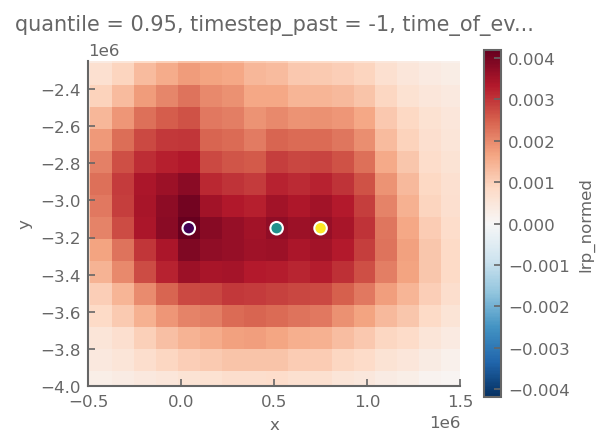

In [367]:
fig, ax = plt.subplots()
data.rolling(x=5, y=5, center=True).mean().plot()
plt.xlim(-.5e6,1.5e6)
plt.ylim(-4e6,-2.25e6)
gdf_patches.set_geometry('location_local_max').plot(cmap='viridis',ax=ax, edgecolor='1')
gdf_patches

In [333]:
data = ds_attrs.sel(time_of_event=time_of_event,timestep_past=timestep_past).lrp_normed
data = data.rio.write_crs(proj) 
img = data.rolling(x=rolling, y=rolling, center=True).mean()
img_filter = img.where(np.abs(img)>abs_threshold).fillna(0)
coords = peak_local_max(img_filter.values)
mask = np.zeros(img.shape, dtype=bool)
mask[tuple(coords.T)] = True
markers, _ = ndi.label(mask)
labels = watershed(-np.abs(img), markers, mask=img)
patch_labels = xr.DataArray(labels, dims=img.dims, coords=img.coords)
# plt.imshow(labels)
# plt.imshow(img.where(np.abs(img)>abs_threshold))
patch_labels = patch_labels.where(np.abs(img)>abs_threshold)
attributions = img.groupby(patch_labels).sum()

gdf_patches = get_gdf_from_segment_grid(patch_labels)
gdf_patches['patch_attributions'] = attributions.values
gdf_patches['patch_area'] = gdf_patches.geometry.area
gdf_patches['patch_pixel_count'] = np.round(gdf_patches.patch_area/117000/117000)
gdf_patches
max_locations = np.array([[img.x[coords[k,0]].values, img.y[coords[k,0]].values] for k in range(gdf_patches.index.size)])

max_locations
# gdf_patches['location_local_max'] = 
gpd.points_from_xy(max_locations[:,0],max_locations[:,1], crs=proj)
# gdf_patches

<GeometryArray>
[<POINT (-2677165.354 -2677165.354)>, <POINT (-3031496.063 -3031496.063)>,
 <POINT (-5866141.732 -5866141.732)>, <POINT (-3858267.717 -3858267.717)>]
Length: 4, dtype: geometry

<Axes: >

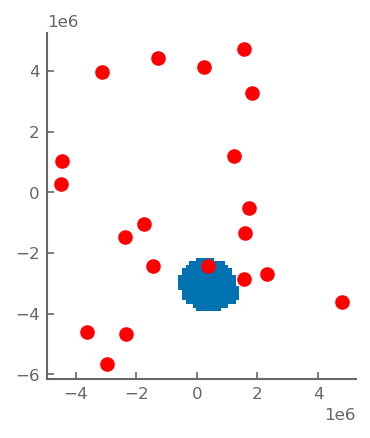

In [304]:
fig, ax = plt.subplots()
gdf_patches.plot(ax=ax)
cyclones_gdf_day.plot(ax=ax, color='red')

<Axes: title={'center': 'quantile = 0.95, timestep_past = -1, time_of_ev...'}, xlabel='x', ylabel='y'>

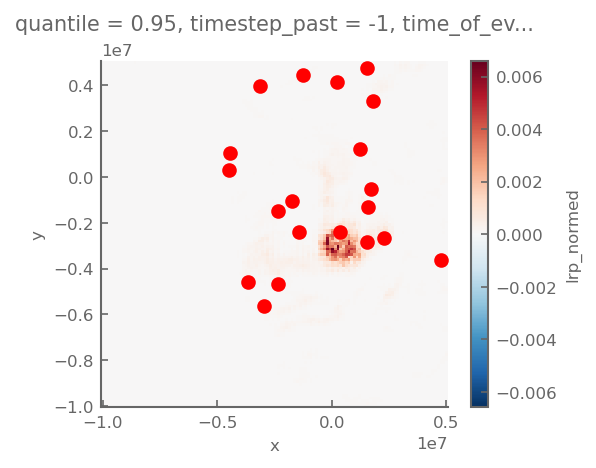

In [307]:
fig, ax = plt.subplots()

data.plot(ax=ax)
cyclones_gdf_day.plot(ax=ax, color='red')

In [283]:
gdf_patches.groupby('cyclone_track_id').agg(dict(patch_attributions='sum', patch_area='sum', patch_pixel_count='sum'))
# .agg(dict(attributions='sum',
#                                                                     #    time_of_event='first',
#                                                                        timestep_past='first',
#                                                                        segment_size='sum')))
# gdf_blob_cycs = gpd.GeoDataFrame(df_blob_cycs, geometry= df_.dissolve(by=['cyclones', 'date','time_of_event']).geometry)

,patch_attributions,patch_area,patch_pixel_count
cyclone_track_id,,,
955154,0.332896,1.925104e+12,141.0
955306,0.125309,8.509517e+11,62.0


<Axes: >

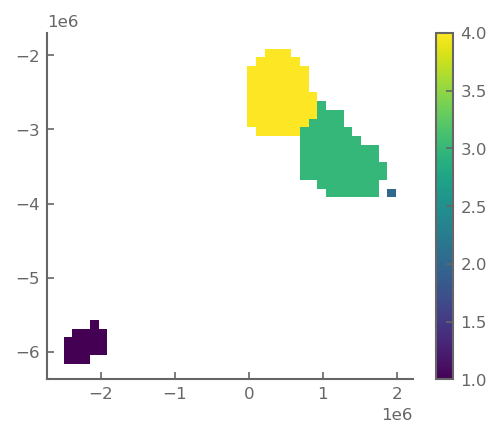

In [214]:
gdf_patches.reset_index().plot(column='label', legend=True)

In [199]:
gdf_patches = segments_from_attribution_grid_watershed(data)
cyclones_gdf_day = get_cyclones_for_day(time_of_event, timestep_past)
intersects500 = get_intersection(gdf_segments, cyclones_gdf_day, buffer=1000_000)
# gdf_segments = attribution_segments(gdf_segments, cyclones_gdf_day, data)
# gdf_segments['time_of_event'] = time_of_event
# gdf_segments['timestep_past'] = timestep_past
intersects500#.plot(cmap='viridis')

,track_id,segment_label,geometry
0,955306,2.0,"POLYGON ((688976.378 -3090551.181, 592395.084 ..."
1,955326,1.0,"POLYGON ((-2145669.291 -5570866.142, -2027559...."
2,955252,1.0,"POLYGON ((-2500000 -5807086.614, -2381889.764 ..."
3,955154,2.0,"POLYGON ((688976.378 -3090551.181, 98425.197 -..."
4,954810,2.0,"POLYGON ((1397637.795 -2972440.945, 1397637.79..."


<Axes: title={'center': 'quantile = 0.95, timestep_past = -2, time_of_ev...'}, xlabel='x', ylabel='y'>

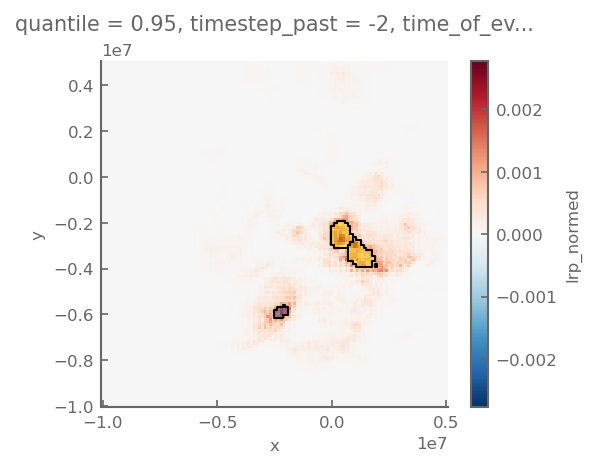

In [ ]:
abs_threshold=0.001



fig, ax = plt.subplots()
data.plot(ax=ax)
segments_from_attribution_grid_watershed(data).plot(column='patch_attributions',ax=ax, alpha=.5)
segments_from_attribution_grid_watershed(data).plot(color='none', edgecolor='k',ax=ax)

ValueError: operands could not be broadcast together with shapes (128,128) (5,5) () 

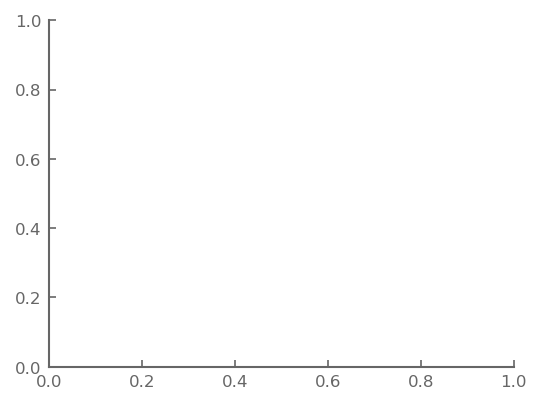

In [127]:
abs_threshold = 0.001
segments, gdf_segments, data = get_segments_gdf_for_day(time_of_event, timestep_past, segments_kwargs=dict(abs_threshold = 0.001, rolling=5))
cyclones_gdf_day = get_cyclones_for_day(time_of_event, timestep_past)
n_patches=gdf_segments.index.size
buffer=500_000
rolling=5
img = data.rolling(x=rolling, y=rolling, center=True).mean()
new_segments = []
for k in range(n_patches):    
    patch = gdf_segments.iloc[k]
    if patch.geometry.area < 117000*117000*1.5:
        continue
    patch_label = gdf_segments.index[k]
    coords = peak_local_max(img.fillna(-1).values)
    mask = np.zeros(img.shape, dtype=bool)
    mask[tuple(coords.T)] = True
    markers, _ = ndi.label(mask)
    labels = watershed(-img, markers, mask=img)

    # intersection_ = cyclones_gdf_day.geometry.buffer(buffer).intersection(patch.geometry)
    # intersection_ = intersection_.loc[intersection_.area>0]
    
    fig, ax = plt.subplots()
    # patch.geometry.plot(ax=ax)
    # intersection_.plot(ax=ax)
    img = data.rolling(x=rolling, y=rolling, center=True).mean().rio.clip([patch.geometry])
    
    plt.imshow(img.where(labels==1))
    plt.imshow(img.where(labels==2), cmap='magma')
# plt.imshow(img)

In [ ]:
limit = Polygon([(-1e7, -1e7), (-1e7, 1e7), (1e7, 1e7), (1e7, -1e7)])
all_voronoi_intersection = []
n_patches=gdf_segments.index.size
# print(n_patches)
for k in range(n_patches):
    patch = gdf_segments.iloc[k]
    patch_label = gdf_segments.index[k]
    intersection_ = cyclones_gdf_day.geometry.buffer(buffer).intersection(patch.geometry)
    intersection_ = intersection_.loc[intersection_.area>0]
    intersection_
    if len(intersection_.index)==0:
        all_voronoi_intersection.append(pd.DataFrame(dict(track_id=['No cyclone'],segment_label=[patch_label],geometry=[patch.geometry])))
    elif len(intersection_.index)==1:
        all_voronoi_intersection.append(pd.DataFrame(dict(track_id=[intersection_.index[0]],segment_label=[patch_label],geometry=[patch.geometry])))
    else:
        voronoi = cyclones_gdf_day.loc[intersection_.index].geometry.voronoi_polygons(extend_to=limit)
        voronoi.index = intersection_.index
        voronoi_intersection = voronoi.intersection(patch.geometry).rename('geometry').reset_index()
        voronoi_intersection['segment_label'] = gdf_segments.index[k]+voronoi_intersection.index/10
        all_voronoi_intersection.append(voronoi_intersection)
if n_patches>0:
    voronoi_out = pd.concat(all_voronoi_intersection)
    voronoi_out = gpd.GeoDataFrame(voronoi_out, geometry='geometry', crs=gdf_segments.crs)
else:
    voronoi_out = gpd.GeoDataFrame(columns=['track_id','segment_label','geometry'], geometry='geometry', crs=gdf_segments.crs)
return voronoi_out


## Get blobs and cyclones together

In [73]:
times = ds_attrs.time_of_event.sel(time_of_event=slice(None, '2024')).values
all_gdf_segments = []
for time_of_event in tqdm(times):
    for timestep_past in range(-6,1):
        segments, gdf_segments, data = get_segments_gdf_for_day(time_of_event, timestep_past, segments_kwargs=dict(abs_threshold = 0.001, rolling=5))
        if gdf_segments.index.size>0:
            cyclones_gdf_day = get_cyclones_for_day(time_of_event, timestep_past)
            gdf_segments = attribution_segments(gdf_segments, cyclones_gdf_day, data)
            gdf_segments['time_of_event'] = time_of_event
            gdf_segments['timestep_past'] = timestep_past
            all_gdf_segments.append(gdf_segments)
df_ = pd.concat(all_gdf_segments)
df_['segment_size'] = df_.area/1_000_000
df_['is_cyclone'] = df_.track_id!='No cyclone'
df_['date'] = df_.time_of_event + pd.Timedelta('1D')*df_.timestep_past
categories = np.array(['                     ' for k in df_.index])
categories[((df_.segment_size<0.1e7)).values] = 'small blob'
categories[((np.abs(df_.attributions)<.05)&(df_.segment_size>0.1e7)).values] = 'large neutral'
categories[((df_.attributions<-.05)&(df_.segment_size>0.1e7)).values] = 'large negative'
categories[((df_.attributions>.05)&(df_.segment_size>0.1e7)).values] = 'large positive'
df_['category'] = categories
df_ = df_.rename(columns=dict(track_id='cyclones'))

  0%|          | 0/840 [00:00<?, ?it/s]

In [74]:
df_blob_cycs = pd.DataFrame(df_.groupby(['cyclones', 'date','time_of_event']).agg(dict(attributions='sum',
                                                                    #    time_of_event='first',
                                                                       timestep_past='first',
                                                                       segment_size='sum')))
gdf_blob_cycs = gpd.GeoDataFrame(df_blob_cycs, geometry= df_.dissolve(by=['cyclones', 'date','time_of_event']).geometry)
categories = np.array(['                     ' for k in df_blob_cycs.index])
categories[((gdf_blob_cycs.segment_size<0.1e7)).values] = 'small blob'
categories[((np.abs(gdf_blob_cycs.attributions)<.1)&(gdf_blob_cycs.segment_size>0.1e7)).values] = 'large neutral'
categories[((gdf_blob_cycs.attributions<-.1)&(gdf_blob_cycs.segment_size>0.1e7)).values] = 'large negative'
categories[((gdf_blob_cycs.attributions>.1)&(gdf_blob_cycs.segment_size>0.1e7)).values] = 'large positive'
gdf_blob_cycs['blob_category'] = categories


key = (gdf_blob_cycs.reset_index().date.dt.strftime("%Y-%m-%d") + ' '+gdf_blob_cycs.reset_index().cyclones.astype(str)).values
key[gdf_blob_cycs.index.get_level_values('cyclones')=='No cyclone'] = '1979-01-02 0'
gdf_blob_cycs['key'] = key
daily_cycs_for_blobs = daily_cycs.reset_index().set_index('key').loc[gdf_blob_cycs.key]
gdf_blob_cycs[['cyclone_msl','cyclone_lon','cyclone_lat','cyclone_x','cyclone_y']] = daily_cycs_for_blobs[['msl','lon','lat','x','y']].values



gdf_blob_cycs = gdf_blob_cycs.reset_index().rename(columns=dict(cyclones='cyclone_track_id', date='cyclone_date',segment_size='blob_area', attributions='blob_attributions'))
gdf_blob_cycs.loc[gdf_blob_cycs.cyclone_track_id=='No cyclone', ['key','cyclone_msl','cyclone_lon','cyclone_lat','cyclone_x','cyclone_y']] = np.nan
gdf_blob_cycs['is_cyclone'] = gdf_blob_cycs.cyclone_track_id != 'No cyclone'

gdf_blob_cycs.to_file(f'/Data/gfi/users/rogui7909/data/NN_outputs/attributions/newproj/{run_id}_cyclones_data_voronoi.geojson', driver='GeoJSON')
# 

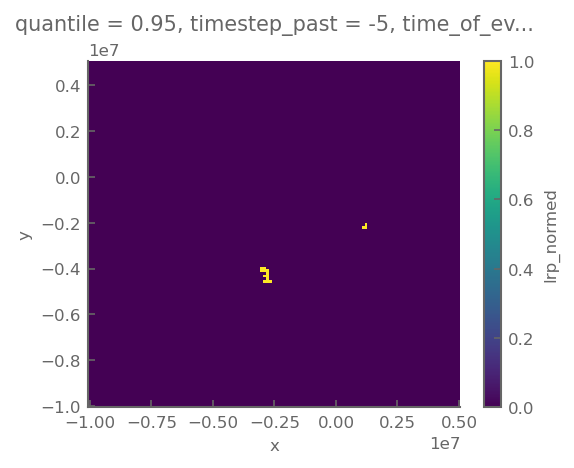

In [53]:
(data.rolling(x=3,y=3).mean()>0.001).plot()

<Axes: >

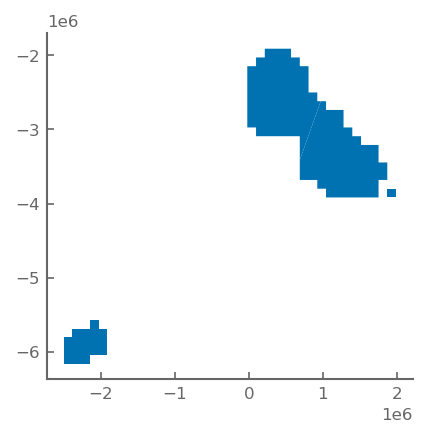

In [ ]:
# cyclones_gdf = gpd.read_file('/Data/gfi/users/rogui7909/data/NN_outputs/attributions/newproj/all_cyclones.geojson')
# data = ds_attrs.lrp_normed.sel(time_of_event='2024-12-18', timestep_past=-2)
# segments, attribution_per_segment = segments_from_attribution_grid(data,)
# segments.plot()
# # data.where(segments==4).plot()
time_of_event='2024-12-18'
timestep_past=-2
segments, gdf_segments, data = get_segments_gdf_for_day(time_of_event, timestep_past, segments_kwargs=dict(abs_threshold = 0.001, rolling=5))
cyclones_gdf_day = get_cyclones_for_day(time_of_event, timestep_past)
gdf_segments = attribution_segments(gdf_segments, cyclones_gdf_day, data)
gdf_segments['time_of_event'] = time_of_event
gdf_segments['timestep_past'] = timestep_past
# all_gdf_segments.append(gdf_segments)

gdf_segments.plot()

In [10]:
data = ds_attrs.isel(time_of_event=1,timestep_past=1).lrp_normed
segments, attribution_per_segment = segments_from_attribution_grid(data,)
gdf_segments = get_gdf_from_segment_grid(segments)
gdf_segments['attributions'] = attribution_per_segment*normalize



In [12]:
buffer = 500_00
intersects = cyclones_gdf_day.geometry.buffer(buffer).apply(lambda g: gdf_segments.intersection(g).loc[gdf_segments.intersects(g)]).dropna(how='all')
intersects = intersects.stack().reset_index()
intersects.columns = ['track_id','segment_label','geometry']
intersects = gpd.GeoDataFrame(intersects, geometry='geometry', crs=gdf_segments.crs)

In [13]:
gdf_segments.area/100_000/100_000

label
1.0    115.785232
2.0    447.795896
3.0     11.160022
4.0     18.135036
5.0     57.195114
6.0      1.395003
7.0    152.055304
8.0    340.380681
9.0    101.835204
dtype: float64

In [45]:
cyclones_gdf_day

,msl,lon,lat,x,y,key,geometry
track_id,,,,,,,
955295,101457.295399,52.843171,38.359314,4.774742e+06,-3.618559e+06,2024-12-16 955295,POINT (4774741.86 -3618559.197)
955305,96937.257282,-164.001743,49.120118,-1.272969e+06,4.439882e+06,2024-12-16 955305,POINT (-1272969.45 4439881.75)
955306,97329.855023,28.761022,60.705619,1.559708e+06,-2.841676e+06,2024-12-16 955306,POINT (1559707.843 -2841675.539)
955308,97675.933090,73.374073,73.570326,1.716686e+06,-5.126122e+05,2024-12-16 955308,POINT (1716685.69 -512612.199)
955326,99772.867962,-26.536371,44.294962,-2.332520e+06,-4.670883e+06,2024-12-16 955326,POINT (-2332519.894 -4670883.454)
955318,100297.656113,-38.304720,39.293480,-3.636884e+06,-4.604314e+06,2024-12-16 955318,POINT (-3636884.365 -4604314.385)
955273,97661.209170,161.987291,46.163591,1.541619e+06,4.741036e+06,2024-12-16 955273,POINT (1541618.55 4741035.6)
955327,99271.013952,-57.968842,64.703879,-2.360044e+06,-1.476504e+06,2024-12-16 955327,POINT (-2360043.928 -1476504.244)
955317,99905.984795,-93.535010,50.164734,-4.482343e+06,2.769011e+05,2024-12-16 955317,POINT (-4482342.878 276901.11)


/tmp/ipykernel_3097433/3792116862.py:4: UserWarning: The GeoSeries you are attempting to plot is composed of empty geometries. Nothing has been displayed.
  cyclones_gdf_day.geometry.buffer(buffer).intersection(gdf_segments.iloc[0].geometry).plot(ax=axs, color='C3')


<Axes: >

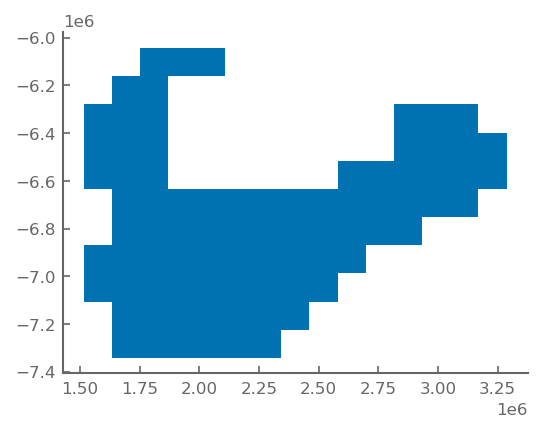

In [14]:
fig, axs = plt.subplots()

gdf_segments.iloc[[0]].plot(ax=axs)
cyclones_gdf_day.geometry.buffer(buffer).intersection(gdf_segments.iloc[0].geometry).plot(ax=axs, color='C3')

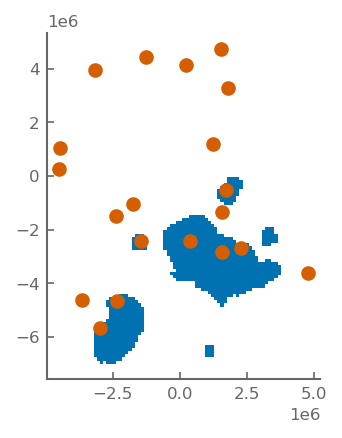

In [15]:
cyclones_gdf_day = get_cyclones_for_day(time_of_event, timestep_past)
        
segments, gdf_segments = get_segments_gdf_for_day(time_of_event, timestep_past, segments_kwargs=dict(abs_threshold = 1, rolling=5))

fig, ax = plt.subplots()
gdf_segments.plot(ax=ax)
cyclones_gdf_day.plot(ax=ax, color='C3')
buffer=500_000
cyclones_per_patch = cyclones_gdf_day.geometry.buffer(buffer).apply(lambda g: gdf_segments.intersection(g).loc[gdf_segments.intersects(g)]).dropna(how='all')
# intersects = cyclones_gdf_day.geometry.buffer(buffer).apply(lambda g: gdf_segments.intersection(g).loc[gdf_segments.intersects(g)]).dropna(how='all')
# intersects = intersects.stack().reset_index()
# intersects.columns = ['track_id','segment_label','geometry']
# intersects = gpd.GeoDataFrame(intersects, geometry='geometry', crs=gdf_segments.crs)

<Axes: >

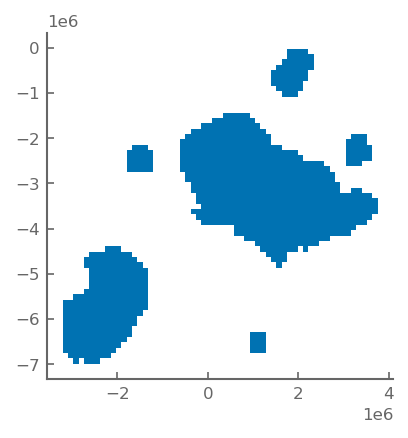

In [30]:
gdf_segments.plot()

In [103]:
cyclones_gdf_day.loc[cyclones_ok].geometry

track_id
954810     POINT (2300083.018 -2687302.882)
955154      POINT (375208.895 -2419758.872)
955181     POINT (1583179.557 -1322636.608)
955252    POINT (-2970464.636 -5647916.396)
955255    POINT (-1435225.551 -2424632.754)
955306     POINT (1559707.843 -2841675.539)
955308       POINT (1716685.69 -512612.199)
955326    POINT (-2332519.894 -4670883.454)
Name: geometry, dtype: geometry

In [129]:
gdf_segments

,geometry,attributions
label,,
1.0,"POLYGON ((-2972440.945 -6988188.976, -2972440....",0.068241
2.0,"POLYGON ((925196.85 -6751968.504, 925196.85 -6...",0.002643
3.0,"POLYGON ((1515748.031 -4862204.724, 1515748.03...",0.219530
4.0,"POLYGON ((-1791338.583 -2736220.472, -1791338....",0.004700
5.0,"POLYGON ((3051181.102 -2618110.236, 3051181.10...",0.004442
6.0,"POLYGON ((1633858.268 -1082677.165, 1633858.26...",0.009088


<Axes: >

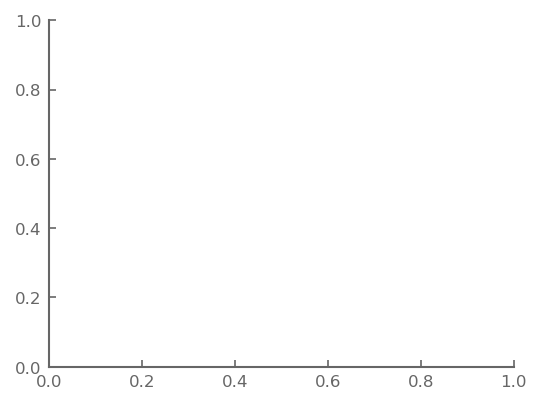

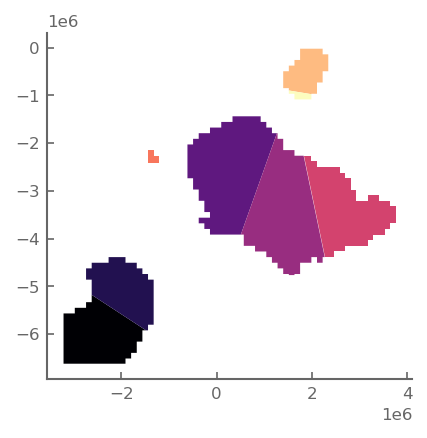

In [ ]:
fig, ax = plt.subplots()
from shapely import LineString, MultiPoint, Point, Polygon
# limit = Polygon([(-100, -100), (0, 15), (15, 15), (15, 0)])
all_voronoi_intersection = []
for k in range(gdf_segments.index.size):
    patch = gdf_segments.iloc[k]
    intersection_ = cyclones_gdf_day.geometry.buffer(buffer).intersection(patch.geometry)
    intersection_ = intersection_.loc[intersection_.area>0]
    intersection_
    voronoi = cyclones_gdf_day.loc[intersection_.index].geometry.voronoi_polygons(extend_to=limit)
    voronoi.index = intersection_.index
    voronoi_intersection = voronoi.intersection(patch.geometry)
    all_voronoi_intersection.append(voronoi_intersection)
return pd.concat(all_voronoi_intersection).plot(cmap='magma')

In [148]:
intersection_ = cyclones_gdf_day.geometry.buffer(buffer).intersection(patch.geometry)
intersection_ = intersection_.loc[intersection_.area>0]
intersection_
if intersection.index.size<0:
    pass

NameError: name 'intersection' is not defined

In [194]:
all_voronoi_intersection[4]

track_id                                           No cyclone
geometry    POLYGON ((3051181.1023622043 -2618110.23622047...
dtype: object

In [196]:
pd.concat(all_voronoi_intersection)

,track_id,geometry
0,955326,"POLYGON ((-3208661.417 -6624949.338, -3208661...."
1,955252,"POLYGON ((-1355486.951 -5807086.614, -1437007...."
0,No cyclone,"POLYGON ((925196.85 -6751968.504, 925196.85 -6..."
0,955306,"POLYGON ((509171.462 -3917322.835, -137795.276..."
1,955154,"POLYGON ((1266443.718 -1791338.583, 1279527.55..."
2,954810,"POLYGON ((1825494.463 -2263779.528, 1988188.97..."
0,955255,"POLYGON ((-1791338.583 -2736220.472, -1791338...."
0,No cyclone,"POLYGON ((3051181.102 -2618110.236, 3051181.10..."
0,955308,"POLYGON ((1515748.031 -895508.446, 1515748.031..."
1,955181,"POLYGON ((1988188.976 -973374.943, 1988188.976..."


<Axes: >

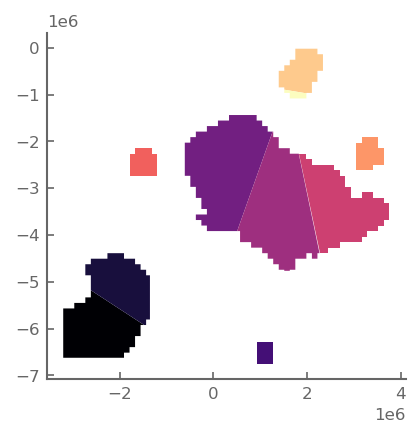

In [ ]:
all_voronoi_intersection = []
for k in range(gdf_segments.index.size):
    patch = gdf_segments.iloc[k]
    intersection_ = cyclones_gdf_day.geometry.buffer(buffer).intersection(patch.geometry)
    intersection_ = intersection_.loc[intersection_.area>0]
    intersection_
    if len(intersection_.index)==0:
        all_voronoi_intersection.append(pd.DataFrame(dict(track_id=['No cyclone'],geometry=[patch.geometry])))
    elif len(intersection_.index)==1:
        all_voronoi_intersection.append(pd.DataFrame(dict(track_id=[intersection_.index[0]],geometry=[patch.geometry])))
    else:
        voronoi = cyclones_gdf_day.loc[intersection_.index].geometry.voronoi_polygons()
        voronoi.index = intersection_.index
        voronoi_intersection = voronoi.intersection(patch.geometry).rename('geometry')
        
        all_voronoi_intersection.append(voronoi_intersection.reset_index())
return pd.concat(all_voronoi_intersection)


In [214]:
gdf_segments

,geometry,attributions
label,,
1.0,"POLYGON ((334645.669 -6397637.795, 334645.669 ...",0.243797
2.0,"POLYGON ((-1791338.583 -6043307.087, -1791338....",0.006710
3.0,"POLYGON ((-3562992.126 -5807086.614, -3562992....",0.000265
4.0,"POLYGON ((-2381889.764 -4035433.071, -2381889....",0.001315
5.0,"POLYGON ((-4271653.543 -3917322.835, -4271653....",0.005086
6.0,"POLYGON ((1751968.504 -2027559.055, 1751968.50...",0.010482
7.0,"POLYGON ((4350393.701 -846456.693, 4350393.701...",0.000810
8.0,"POLYGON ((2106299.213 1279527.559, 2106299.213...",0.003177
9.0,"POLYGON ((807086.614 3169291.339, 807086.614 3...",0.006998


In [213]:
get_intersection(gdf_segments, cyclones_gdf_day, buffer=500_000 )


,track_id,segment_label,geometry
0,67,1.0,"POLYGON ((2424819.094 -4593073.628, 2417619.37..."
1,63,1.0,"POLYGON ((1586827.679 -5144845.087, 1579627.95..."
2,22,7.0,"POLYGON ((4350393.701 -831771.939, 4396736.044..."
3,95,1.0,"POLYGON ((3246149.519 -4071454.836, 3238949.79..."


1.0
2.0
3.0
4.0
5.0
6.0
7.0
8.0
9.0


<Axes: >

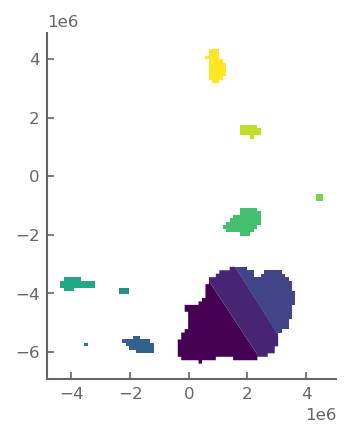

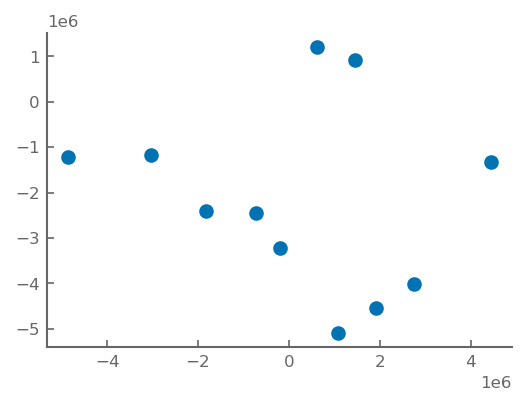

In [237]:
get_intersection_voronoi(gdf_segments, cyclones_gdf_day, buffer=500_000 ).plot(cmap='viridis')

cyclones_gdf_day.plot()

<Axes: >

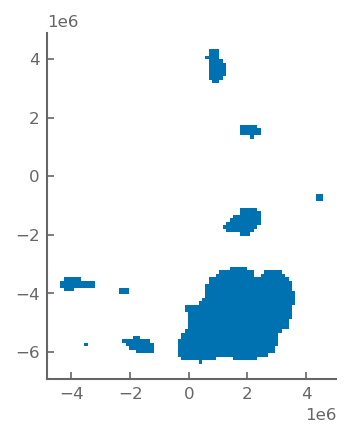

In [233]:
gdf_segments.plot()

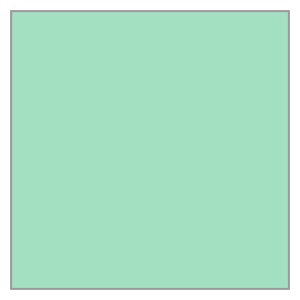

In [ ]:
limit = Polygon([(-1e7, -1e7), (-1e7, 1e7), (1e7, 1e7), (1e7, 0)])
limit

In [383]:
def segments_from_attribution_grid(data, abs_threshold = 1, rolling=3):
    data_rolling = data.rolling(x=rolling,y=rolling,center=True).mean().fillna(0)
    data_rolling = data_rolling.where(np.abs(data_rolling)>abs_threshold,0)
    img = data_rolling.values
    img = img#/img.max()
    segments_fz, num_features = scipy.ndimage.label(img, structure=[[1,1,1],[1,1,1],[1,1,1],])
    segments = xr.DataArray(segments_fz, dims=data.dims, coords=data.coords)
    attribution_per_segment = data.groupby(segments).sum().to_series().rename('attributions')
    return segments, attribution_per_segment

def get_gdf_from_segment_grid(segments):
    x = segments.x.values
    y = segments.y.values
    labels = segments.values
    dx = float(np.mean(np.diff(x))) 
    dy = float(np.mean(np.diff(y))) 
    x0 = x.min() - dx / 2.0
    y0 = y.min() - dy / 2.0  
    transform = Affine.translation(x0, y0) * Affine.scale(dx, dy)
    geoms = []
    vals = []
    for geom, value in features.shapes(labels, transform=transform):
        if value == 0:
            continue
        geoms.append(shape(geom))
        vals.append(value)
    gdf_segments = gpd.GeoDataFrame(
        {"label": vals},
        geometry=geoms,
        crs="EPSG:3413"   # or "EPSG:3995" or your custom proj string
    )
    gdf_segments= gdf_segments.set_index('label') 
    gdf_segments=gdf_segments.reset_index().dissolve(by='label')
    return gdf_segments

def get_segments_gdf_for_day(time_of_event, timestep_past, segments_kwargs=dict()):
    data = ds_attrs.sel(time_of_event=time_of_event,timestep_past=timestep_past).lrp_normed
    segments, attribution_per_segment = segments_from_attribution_grid(data, **segments_kwargs)
    gdf_segments = get_gdf_from_segment_grid(segments)
    gdf_segments['attributions'] = attribution_per_segment*normalize
    return segments, gdf_segments, data

def get_cyclones_for_day(time_of_event, timestep_past):
    time = pd.to_datetime(time_of_event) + pd.Timedelta(f'{timestep_past}D')
    cyclones_gdf_day = cyclones_gdf.loc[time.strftime("%Y-%m-%d")]
    return cyclones_gdf_day.set_index('track_id')

def get_intersection(gdf_segments, cyclones_gdf_day, buffer=500_000):
    intersects = cyclones_gdf_day.geometry.buffer(buffer).apply(lambda g: gdf_segments.intersection(g).loc[gdf_segments.intersects(g)]).dropna(how='all')
    intersects = intersects.stack().reset_index()
    intersects.columns = ['track_id','segment_label','geometry']
    intersects = gpd.GeoDataFrame(intersects, geometry='geometry', crs=gdf_segments.crs)
    return intersects

def get_intersection_voronoi(gdf_segments, cyclones_gdf_day, buffer=500_000):
    limit = Polygon([(-1e7, -1e7), (-1e7, 1e7), (1e7, 1e7), (1e7, -1e7)])
    all_voronoi_intersection = []
    for k in range(gdf_segments.index.size):
        patch = gdf_segments.iloc[k]
        patch_label = gdf_segments.index[k]
        intersection_ = cyclones_gdf_day.geometry.buffer(buffer).intersection(patch.geometry)
        intersection_ = intersection_.loc[intersection_.area>0]
        intersection_
        if len(intersection_.index)==0:
            all_voronoi_intersection.append(pd.DataFrame(dict(track_id=['No cyclone'],segment_label=[patch_label],geometry=[patch.geometry])))
        elif len(intersection_.index)==1:
            all_voronoi_intersection.append(pd.DataFrame(dict(track_id=[intersection_.index[0]],segment_label=[patch_label],geometry=[patch.geometry])))
        else:
            voronoi = cyclones_gdf_day.loc[intersection_.index].geometry.voronoi_polygons(extend_to=limit)
            voronoi.index = intersection_.index
            voronoi_intersection = voronoi.intersection(patch.geometry).rename('geometry').reset_index()
            voronoi_intersection['segment_label'] = gdf_segments.index[k]+voronoi_intersection.index/10
            all_voronoi_intersection.append(voronoi_intersection)

    voronoi_out = pd.concat(all_voronoi_intersection)
    voronoi_out = gpd.GeoDataFrame(voronoi_out, geometry='geometry', crs=gdf_segments.crs)
    return voronoi_out

def get_attributions(data,voronoi_intersections ):
    data = data.rio.write_crs(proj) 
    mask = xr.full_like(data, np.nan)

    for i, poly in enumerate(voronoi_intersections.geometry):
        clipped = data.rio.clip([poly], drop=False)
        mask = mask.where(clipped.isnull(), i + 1)
    mask = mask.rename("region")
    attributions = (data.groupby(mask).sum()*normalize).to_series()
    attributions = attributions.reindex(np.arange(1, voronoi_intersections.shape[0]+1)).fillna(0)
    attributions.index = voronoi_intersections.segment_label    
    return attributions

def attribution_segments(gdf_segments, cyclones_gdf_day, data):
    intersects500= get_intersection_voronoi(gdf_segments, cyclones_gdf_day, buffer=500_000)
    intersects500['area'] = intersects500.geometry.area
    intersects500 = intersects500.loc[intersects500.area>0]
    attributions = get_attributions(data,intersects500 )
    intersects500 = intersects500.set_index('segment_label')
    intersects500['attributions'] = attributions

    intersects500 = intersects500.loc[intersects500.attributions!=0]
    # gdf_segments['cyclones'] = intersects500.set_index('track_id').groupby('segment_label').area.idxmax()
    return intersects500.reset_index()



In [373]:
segments, gdf_segments, data = get_segments_gdf_for_day(time_of_event, timestep_past, segments_kwargs=dict(abs_threshold = 1, rolling=5))
cyclones_gdf_day = get_cyclones_for_day(time_of_event, timestep_past)
        
intersects500 = get_intersection_voronoi(gdf_segments, cyclones_gdf_day, buffer=500_000)
intersects500['area'] = intersects500.geometry.area
intersects500 = intersects500.loc[intersects500.area>0]
voronoi_intersections = intersects500
data = data.rio.write_crs(proj) 
mask = xr.full_like(data, np.nan)

for i, poly in enumerate(voronoi_intersections.geometry):
    clipped = data.rio.clip([poly], drop=False)
    mask = mask.where(clipped.isnull(), i + 1)
mask = mask.rename("region")
attributions = (data.groupby(mask).sum()*normalize).to_series()
attributions = attributions.reindex(np.arange(1,voronoi_intersections.segment_label.size+1)).fillna(0)
attributions.index = voronoi_intersections.segment_label    

# attributions = get_attributions(data,intersects500 )
# intersects500 = intersects500.set_index('segment_label')
# intersects500['attributions'] = attributions


## Get blobs and cyclones together

In [ ]:
times = ds_attrs.time_of_event.sel(time_of_event=slice(None, '2024')).values
all_gdf_segments = []
for time_of_event in tqdm(times):
    for timestep_past in range(-6,1):
        segments, gdf_segments, data = get_segments_gdf_for_day(time_of_event, timestep_past, segments_kwargs=dict(abs_threshold = 1, rolling=5))
        cyclones_gdf_day = get_cyclones_for_day(time_of_event, timestep_past)
        gdf_segments = attribution_segments(gdf_segments, cyclones_gdf_day, data)
        gdf_segments['time_of_event'] = time_of_event
        gdf_segments['timestep_past'] = timestep_past
        all_gdf_segments.append(gdf_segments)
df_ = pd.concat(all_gdf_segments)
df_['segment_size'] = df_.area/1_000_000
df_['is_cyclone'] = df_.track_id!='No cyclone'
df_['date'] = df_.time_of_event + pd.Timedelta('1D')*df_.timestep_past
categories = np.array(['                     ' for k in df_.index])
categories[((df_.segment_size<0.1e7)).values] = 'small blob'
categories[((np.abs(df_.attributions)<.05)&(df_.segment_size>0.1e7)).values] = 'large neutral'
categories[((df_.attributions<-.05)&(df_.segment_size>0.1e7)).values] = 'large negative'
categories[((df_.attributions>.05)&(df_.segment_size>0.1e7)).values] = 'large positive'
df_['category'] = categories
df_ = df_.rename(columns=dict(track_id='cyclones'))

  0%|          | 0/840 [00:00<?, ?it/s]

In [399]:
df_

,segment_label,cyclones,geometry,area,attributions,time_of_event,timestep_past,segment_size,is_cyclone,date,category
0,1.0,67,"POLYGON ((2391513.279 -6161417.323, 2342519.68...",4.140172e+12,0.110952,1979-01-07,-6,4.140172e+06,True,1979-01-01,large positive
1,1.1,63,"POLYGON ((688976.378 -3575724.853, 688976.378 ...",3.126672e+12,0.078671,1979-01-07,-6,3.126672e+06,True,1979-01-01,large positive
2,1.2,95,"POLYGON ((1580417.178 -3090551.181, 1988188.97...",2.400525e+12,0.054174,1979-01-07,-6,2.400525e+06,True,1979-01-01,large positive
3,2.0,No cyclone,"POLYGON ((-1791338.583 -6043307.087, -1791338....",4.185008e+11,0.006710,1979-01-07,-6,4.185008e+05,False,1979-01-01,small blob
4,3.0,No cyclone,"POLYGON ((-3562992.126 -5807086.614, -3562992....",1.395003e+10,0.000265,1979-01-07,-6,1.395003e+04,False,1979-01-01,small blob
...,...,...,...,...,...,...,...,...,...,...,...
2,2.1,955944,"POLYGON ((-748208.615 -3444881.89, -610236.22 ...",3.045310e+12,0.084692,2024-12-29,0,3.045310e+06,True,2024-12-29,large positive
3,2.2,955824,"POLYGON ((-492125.984 -1314185.217, -492125.98...",3.348592e+12,0.155379,2024-12-29,0,3.348592e+06,True,2024-12-29,large positive
4,2.3,955745,"POLYGON ((-324391.2 -610236.22, 334645.669 -61...",9.771914e+11,0.016679,2024-12-29,0,9.771914e+05,True,2024-12-29,small blob
5,3.0,No cyclone,"POLYGON ((-728346.457 -374015.748, -728346.457...",4.185008e+11,0.005522,2024-12-29,0,4.185008e+05,False,2024-12-29,small blob


In [403]:
daily_cycs

,track_id,msl,lon,lat,x,y,key
date,,,,,,,
1979-01-01,0,100487.303602,-76.048833,45.989150,-4.859531e+06,-1.207219e+06,1979-01-01 0
1979-01-01,101,97338.043428,122.049854,74.149758,1.464296e+06,9.167662e+05,1979-01-01 101
1979-01-01,67,98855.651712,22.982749,46.559554,1.927227e+06,-4.544065e+06,1979-01-01 67
1979-01-01,63,98734.763447,12.065410,44.373426,1.089235e+06,-5.095837e+06,1979-01-01 63
1979-01-01,22,100754.987498,73.433667,48.961326,4.445745e+06,-1.322490e+06,1979-01-01 22
...,...,...,...,...,...,...,...
2024-12-30,955856,100503.970350,-102.183367,57.591066,-3.522528e+06,7.605272e+05,2024-12-30 955856
2024-12-30,955852,101709.656783,6.671551,19.660674,1.011669e+06,-8.648989e+06,2024-12-30 955852
2024-12-30,955944,96591.911384,24.654133,71.221191,8.559414e+05,-1.864881e+06,2024-12-30 955944


In [408]:
gdf_blob_cycs

attributions  timestep_past  \
cyclones   date       time_of_event                                
0          1979-01-02 1979-01-07         0.005861             -5   
9          1979-01-02 1979-01-07         0.001201             -5   
           1979-01-05 1979-01-07         0.006093             -2   
           1979-01-06 1979-01-07         0.025292             -1   
13         1979-01-02 1979-01-07         0.005436             -5   
...                                           ...            ...   
No cyclone 2024-12-25 2024-12-29         0.039176             -4   
           2024-12-26 2024-12-29         0.010852             -3   
           2024-12-27 2024-12-29         0.004621             -2   
           2024-12-28 2024-12-29         0.005004             -1   
           2024-12-29 2024-12-29         0.013582              0   

                                     segment_size  \
cyclones   date       time_of_event                 
0          1979-01-02 1979-01-07     4.185008e+05   
9          1979-01-02 1979-01-07     5.580011e+04   
           1979-01-05 1979-01-07     4.250000e+05   
           1979-01-06 1979-01-07     7.709402e+05   
13         1979-01-02 1979-01-07     4.045508e+05   
...                                           ...   
No cyclone 2024-12-25 2024-12-29     2.915556e+06   
           2024-12-26 2024-12-29     7.254015e+05   
           2024-12-27 2024-12-29     2.929506e+05   
           2024-12-28 2024-12-29     3.208506e+05   
           2024-12-29 2024-12-29     9.904520e+05   

                                                                              geometry  \
cyclones   date       time_of_event                                                      
0          1979-01-02 1979-01-07     POLYGON ((-4862204.724 -2263779.528, -4862204....   
9          1979-01-02 1979-01-07     POLYGON ((-728346.457 -2381889.764, -728346.45...   
           1979-01-05 1979-01-07     MULTIPOLYGON (((98425.197 -1909448.819, -19685...   
           1979-01-06 1979-01-07     POLYGON ((-654079.13 -2049676.014, -1298769.41...   
13         1979-01-02 1979-01-07     POLYGON ((216535.433 -1082677.165, 216535.433 ...   
...                                                                                ...   
No cyclone 2024-12-25 2024-12-29     MULTIPOLYGON (((1633858.268 -6870078.74, 16338...   
           2024-12-26 2024-12-29     MULTIPOLYGON (((2342519.685 -6751968.504, 2696...   
           2024-12-27 2024-12-29     MULTIPOLYGON (((3641732.283 -5807086.614, 3877...   
           2024-12-28 2024-12-29     POLYGON ((2342519.685 -5570866.142, 2342519.68...   
           2024-12-29 2024-12-29     MULTIPOLYGON (((-1318897.638 -4744094.488, -12...   

                                     blob_category                    key  
cyclones   date       time_of_event                                        
0          1979-01-02 1979-01-07        small blob           1979-01-02 0  
9          1979-01-02 1979-01-07        small blob           1979-01-02 9  
           1979-01-05 1979-01-07        small blob           1979-01-05 9  
           1979-01-06 1979-01-07        small blob           1979-01-06 9  
13         1979-01-02 1979-01-07        small blob          1979-01-02 13  
...                                            ...                    ...  
No cyclone 2024-12-25 2024-12-29     large neutral  2024-12-25 No cyclone  
           2024-12-26 2024-12-29        small blob  2024-12-26 No cyclone  
           2024-12-27 2024-12-29        small blob  2024-12-27 No cyclone  
           2024-12-28 2024-12-29        small blob  2024-12-28 No cyclone  
           2024-12-29 2024-12-29        small blob  2024-12-29 No cyclone  

[33996 rows x 6 columns]

In [409]:
df_blob_cycs

attributions  timestep_past  segment_size
cyclones   date       time_of_event                                           
0          1979-01-02 1979-01-07         0.005861             -5  4.185008e+05
9          1979-01-02 1979-01-07         0.001201             -5  5.580011e+04
           1979-01-05 1979-01-07         0.006093             -2  4.250000e+05
           1979-01-06 1979-01-07         0.025292             -1  7.709402e+05
13         1979-01-02 1979-01-07         0.005436             -5  4.045508e+05
...                                           ...            ...           ...
No cyclone 2024-12-25 2024-12-29         0.039176             -4  2.915556e+06
           2024-12-26 2024-12-29         0.010852             -3  7.254015e+05
           2024-12-27 2024-12-29         0.004621             -2  2.929506e+05
           2024-12-28 2024-12-29         0.005004             -1  3.208506e+05
           2024-12-29 2024-12-29         0.013582              0  9.904520e+05

[33996 rows x 3 columns]

In [414]:
gdf_blob_cycs

attributions  timestep_past  \
cyclones   date       time_of_event                                
0          1979-01-02 1979-01-07         0.005861             -5   
9          1979-01-02 1979-01-07         0.001201             -5   
           1979-01-05 1979-01-07         0.006093             -2   
           1979-01-06 1979-01-07         0.025292             -1   
13         1979-01-02 1979-01-07         0.005436             -5   
...                                           ...            ...   
No cyclone 2024-12-25 2024-12-29         0.039176             -4   
           2024-12-26 2024-12-29         0.010852             -3   
           2024-12-27 2024-12-29         0.004621             -2   
           2024-12-28 2024-12-29         0.005004             -1   
           2024-12-29 2024-12-29         0.013582              0   

                                     segment_size  \
cyclones   date       time_of_event                 
0          1979-01-02 1979-01-07     4.185008e+05   
9          1979-01-02 1979-01-07     5.580011e+04   
           1979-01-05 1979-01-07     4.250000e+05   
           1979-01-06 1979-01-07     7.709402e+05   
13         1979-01-02 1979-01-07     4.045508e+05   
...                                           ...   
No cyclone 2024-12-25 2024-12-29     2.915556e+06   
           2024-12-26 2024-12-29     7.254015e+05   
           2024-12-27 2024-12-29     2.929506e+05   
           2024-12-28 2024-12-29     3.208506e+05   
           2024-12-29 2024-12-29     9.904520e+05   

                                                                              geometry  \
cyclones   date       time_of_event                                                      
0          1979-01-02 1979-01-07     POLYGON ((-4862204.724 -2263779.528, -4862204....   
9          1979-01-02 1979-01-07     POLYGON ((-728346.457 -2381889.764, -728346.45...   
           1979-01-05 1979-01-07     MULTIPOLYGON (((98425.197 -1909448.819, -19685...   
           1979-01-06 1979-01-07     POLYGON ((-654079.13 -2049676.014, -1298769.41...   
13         1979-01-02 1979-01-07     POLYGON ((216535.433 -1082677.165, 216535.433 ...   
...                                                                                ...   
No cyclone 2024-12-25 2024-12-29     MULTIPOLYGON (((1633858.268 -6870078.74, 16338...   
           2024-12-26 2024-12-29     MULTIPOLYGON (((2342519.685 -6751968.504, 2696...   
           2024-12-27 2024-12-29     MULTIPOLYGON (((3641732.283 -5807086.614, 3877...   
           2024-12-28 2024-12-29     POLYGON ((2342519.685 -5570866.142, 2342519.68...   
           2024-12-29 2024-12-29     MULTIPOLYGON (((-1318897.638 -4744094.488, -12...   

                                     blob_category                    key  
cyclones   date       time_of_event                                        
0          1979-01-02 1979-01-07        small blob           1979-01-02 0  
9          1979-01-02 1979-01-07        small blob           1979-01-02 9  
           1979-01-05 1979-01-07        small blob           1979-01-05 9  
           1979-01-06 1979-01-07        small blob           1979-01-06 9  
13         1979-01-02 1979-01-07        small blob          1979-01-02 13  
...                                            ...                    ...  
No cyclone 2024-12-25 2024-12-29     large neutral  2024-12-25 No cyclone  
           2024-12-26 2024-12-29        small blob  2024-12-26 No cyclone  
           2024-12-27 2024-12-29        small blob  2024-12-27 No cyclone  
           2024-12-28 2024-12-29        small blob  2024-12-28 No cyclone  
           2024-12-29 2024-12-29        small blob  2024-12-29 No cyclone  

[33996 rows x 6 columns]

In [ ]:
df_blob_cycs = pd.DataFrame(df_.groupby(['cyclones', 'date','time_of_event']).agg(dict(attributions='sum',
                                                                    #    time_of_event='first',
                                                                       timestep_past='first',
                                                                       segment_size='sum')))
gdf_blob_cycs = gpd.GeoDataFrame(df_blob_cycs, geometry= df_.dissolve(by=['cyclones', 'date','time_of_event']).geometry)
categories = np.array(['                     ' for k in df_blob_cycs.index])
categories[((gdf_blob_cycs.segment_size<0.1e7)).values] = 'small blob'
categories[((np.abs(gdf_blob_cycs.attributions)<.1)&(gdf_blob_cycs.segment_size>0.1e7)).values] = 'large neutral'
categories[((gdf_blob_cycs.attributions<-.1)&(gdf_blob_cycs.segment_size>0.1e7)).values] = 'large negative'
categories[((gdf_blob_cycs.attributions>.1)&(gdf_blob_cycs.segment_size>0.1e7)).values] = 'large positive'
gdf_blob_cycs['blob_category'] = categories


key = (gdf_blob_cycs.reset_index().date.dt.strftime("%Y-%m-%d") + ' '+gdf_blob_cycs.reset_index().cyclones.astype(str)).values
key[gdf_blob_cycs.index.get_level_values('cyclones')=='No cyclone'] = '1979-01-02 0'
gdf_blob_cycs['key'] = key
daily_cycs_for_blobs = daily_cycs.reset_index().set_index('key').loc[gdf_blob_cycs.key]
gdf_blob_cycs[['cyclone_msl','cyclone_lon','cyclone_lat','cyclone_x','cyclone_y']] = daily_cycs_for_blobs[['msl','lon','lat','x','y']].values



gdf_blob_cycs = gdf_blob_cycs.reset_index().rename(columns=dict(cyclones='cyclone_track_id', date='cyclone_date',segment_size='blob_area', attributions='blob_attributions'))
gdf_blob_cycs.loc[gdf_blob_cycs.cyclone_track_id=='No cyclone', ['key','cyclone_msl','cyclone_lon','cyclone_lat','cyclone_x','cyclone_y']] = np.nan
gdf_blob_cycs['is_cyclone'] = gdf_blob_cycs.cyclone_track_id != 'No cyclone'

gdf_blob_cycs.to_file(f'/Data/gfi/users/rogui7909/data/NN_outputs/attributions/newproj/{run_id}_cyclones_data_voronoi.geojson', driver='GeoJSON')
# 

In [ ]:
df_.query("is_cyclone & blob_category=='large positive'").set_index(['time_of_event','timestep_past'])['count']

blob_category  is_cyclone  count
time_of_event timestep_past                                   
1979-01-07    -6             large positive        True      1
              -5             large positive        True      1
              -4             large positive        True      1
              -3             large positive        True      1
              -2             large positive        True      1
...                                     ...         ...    ...
2024-12-29    -4             large positive        True      1
              -3             large positive        True      1
              -2             large positive        True      1
              -1             large positive        True      1
               0             large positive        True      1

[5844 rows x 3 columns]

In [115]:
times.size*7

5880

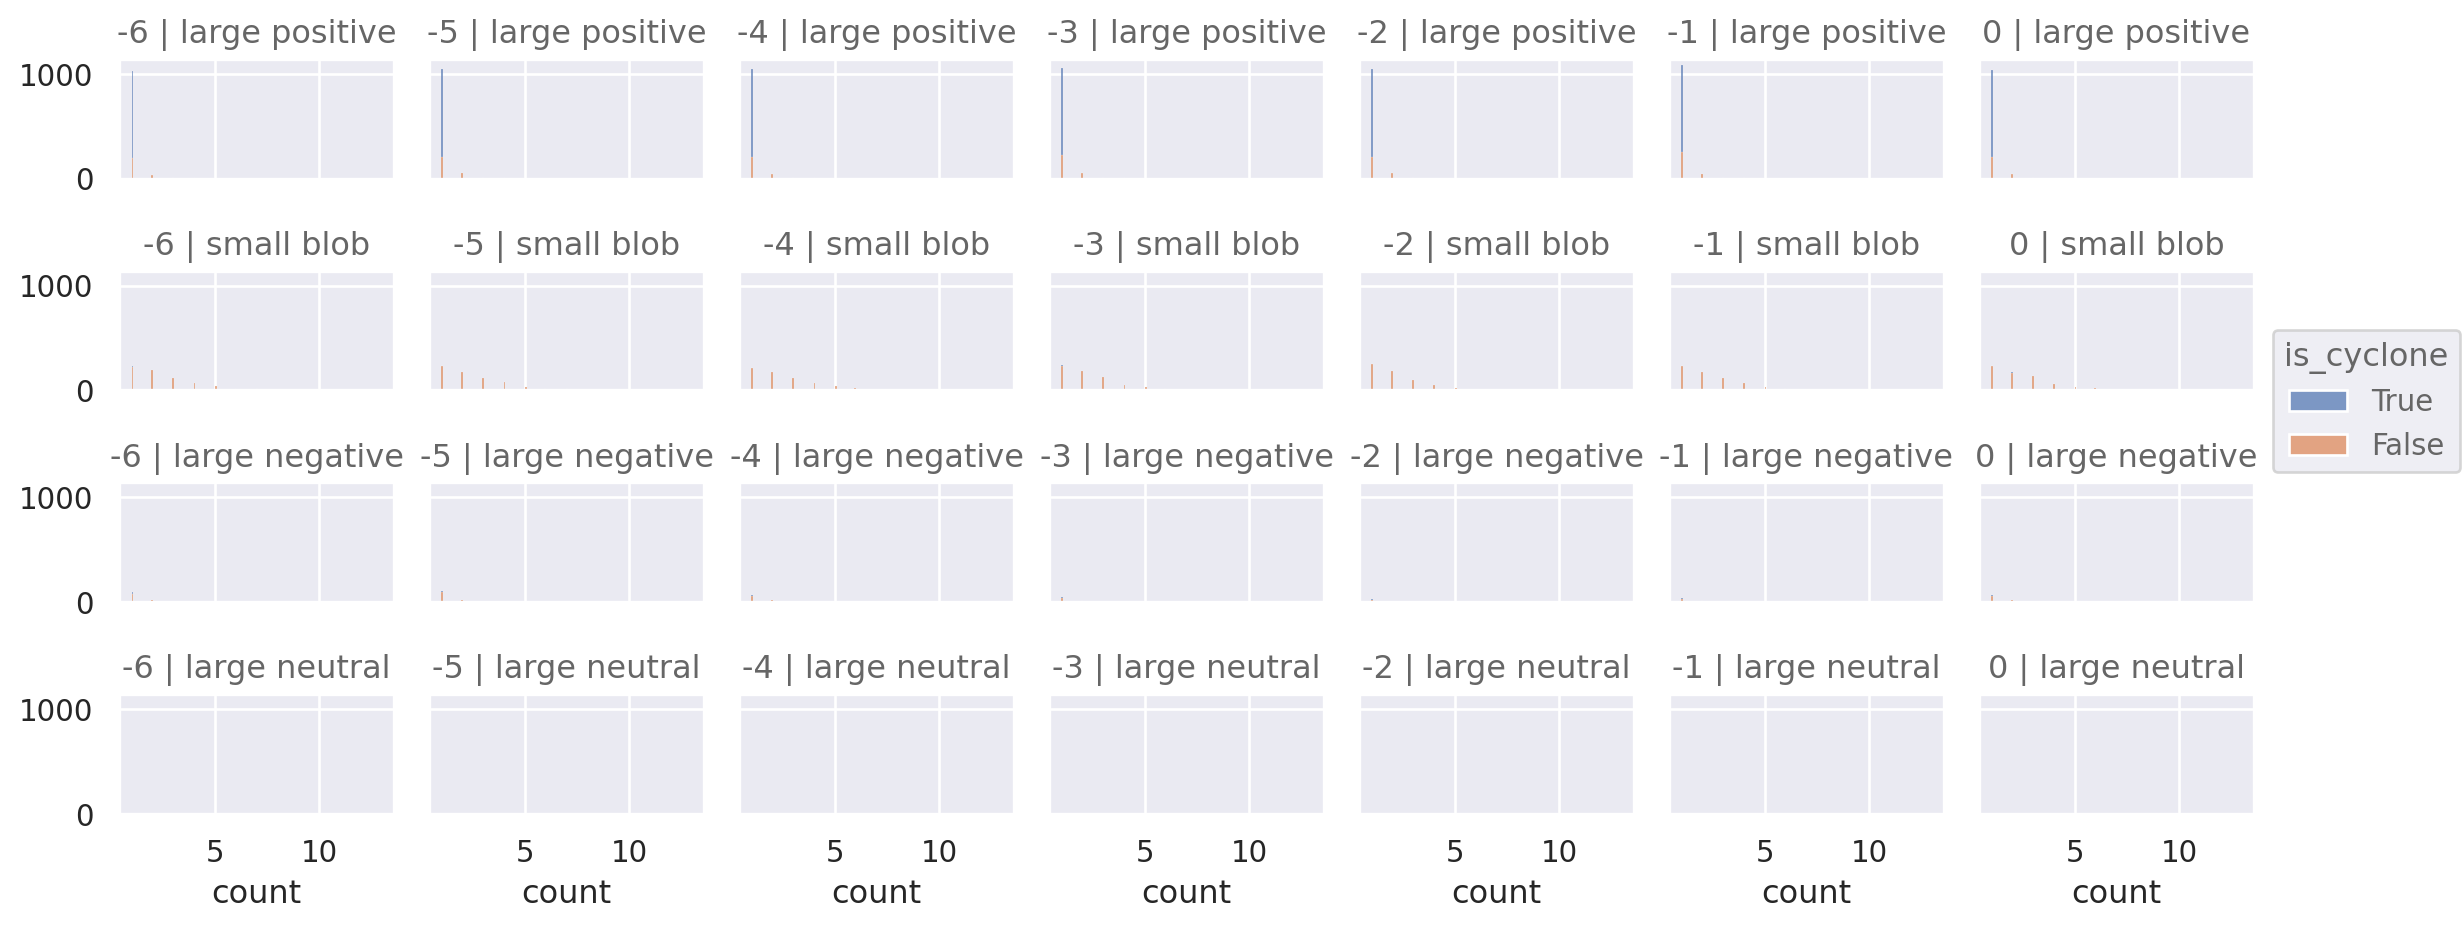

In [94]:
df_ = gdf_out.groupby(['time_of_event','timestep_past','blob_category','is_cyclone']).blob_area.count().rename('count').reset_index()

(so.Plot(df_, x='count', color='is_cyclone')
 .add(so.Bars(), so.Hist(), so.Stack())
 .facet(row='blob_category', col='timestep_past')
 .layout(size=(12,5))
 )

In [19]:
gdf_out.groupby(['time_of_event','timestep_past','cyclone_region']).geometry.count().rename('count')

KeyError: 'cyclone_region'

In [42]:
daily_cycs.reset_index().set_index('key')

,date,track_id,msl,lon,lat,x,y
key,,,,,,,
1979-01-01 0,1979-01-01,0,100487.303602,-76.048833,45.989150,-4.859531e+06,-1.207219e+06
1979-01-01 101,1979-01-01,101,97338.043428,122.049854,74.149758,1.464296e+06,9.167662e+05
1979-01-01 67,1979-01-01,67,98855.651712,22.982749,46.559554,1.927227e+06,-4.544065e+06
1979-01-01 63,1979-01-01,63,98734.763447,12.065410,44.373426,1.089235e+06,-5.095837e+06
1979-01-01 22,1979-01-01,22,100754.987498,73.433667,48.961326,4.445745e+06,-1.322490e+06
...,...,...,...,...,...,...,...
2024-12-30 955856,2024-12-30,955856,100503.970350,-102.183367,57.591066,-3.522528e+06,7.605272e+05
2024-12-30 955852,2024-12-30,955852,101709.656783,6.671551,19.660674,1.011669e+06,-8.648989e+06
2024-12-30 955944,2024-12-30,955944,96591.911384,24.654133,71.221191,8.559414e+05,-1.864881e+06


In [36]:
gdf_blob_cycs

attributions  timestep_past  segment_size  \
cyclones date       time_of_event                                              
0.0      1979-01-02 1979-01-07         0.057921             -5  8.788518e+05   
5.0      1979-01-01 1979-01-07         0.022079             -6  3.348007e+05   
9.0      1979-01-01 1979-01-07         0.009593             -6  1.813504e+05   
         1979-01-02 1979-01-07         0.046147             -5  5.859012e+05   
         1979-01-03 1979-01-07         0.019342             -4  2.790006e+05   
...                                         ...            ...           ...   
229100.0 1990-03-22 1990-03-24        -0.031381             -2  5.859012e+05   
229107.0 1990-03-23 1990-03-24        -0.019938             -1  3.487507e+05   
229184.0 1990-03-23 1990-03-23         0.765003              0  5.538161e+06   
                    1990-03-24         0.769151             -1  5.580011e+06   
         1990-03-24 1990-03-24         0.765517              0  4.575609e+06   

                                                                            geometry  \
cyclones date       time_of_event                                                      
0.0      1979-01-02 1979-01-07     POLYGON ((-4507874.016 -2972440.945, -4507874....   
5.0      1979-01-01 1979-01-07     POLYGON ((-2145669.291 -2972440.945, -2145669....   
9.0      1979-01-01 1979-01-07     POLYGON ((-964566.929 -2854330.709, -964566.92...   
         1979-01-02 1979-01-07     POLYGON ((-728346.457 -2736220.472, -728346.45...   
         1979-01-03 1979-01-07     MULTIPOLYGON (((-19685.039 -2500000, 216535.43...   
...                                                                              ...   
229100.0 1990-03-22 1990-03-24     POLYGON ((1751968.504 -3090551.181, 1751968.50...   
229107.0 1990-03-23 1990-03-24     POLYGON ((-3562992.126 -2381889.764, -3562992....   
229184.0 1990-03-23 1990-03-23     POLYGON ((-1200787.402 -4153543.307, -1200787....   
                    1990-03-24     POLYGON ((-1437007.874 -4271653.543, -1437007....   
         1990-03-24 1990-03-24     POLYGON ((452755.906 -4035433.071, 452755.906 ...   

                                    blob_category                  key  
cyclones date       time_of_event                                       
0.0      1979-01-02 1979-01-07         small blob       1979-01-02 0.0  
5.0      1979-01-01 1979-01-07         small blob       1979-01-01 5.0  
9.0      1979-01-01 1979-01-07         small blob       1979-01-01 9.0  
         1979-01-02 1979-01-07         small blob       1979-01-02 9.0  
         1979-01-03 1979-01-07         small blob       1979-01-03 9.0  
...                                           ...                  ...  
229100.0 1990-03-22 1990-03-24         small blob  1990-03-22 229100.0  
229107.0 1990-03-23 1990-03-24         small blob  1990-03-23 229107.0  
229184.0 1990-03-23 1990-03-23     large positive  1990-03-23 229184.0  
                    1990-03-24     large positive  1990-03-23 229184.0  
         1990-03-24 1990-03-24     large positive  1990-03-24 229184.0  

[4528 rows x 6 columns]

# Compute model skills

In [46]:
gdf_blob_cycs.reset_index()#.iloc[:10].plot()

,cyclones,date,time_of_event,attributions,timestep_past,segment_size,geometry,blob_category,key,cyclone_msl,cyclone_lon,cyclone_lat,cyclone_x,cyclone_y,cyclone_region
0,0.0,1979-01-02,1979-01-07,0.133534,-5,1.605536e+06,"POLYGON ((-4764705.882 -2411764.706, -4764705....",large positive,1979-01-02 0.0,100748.992025,-63.887996,50.383825,-4.008538e+06,-1.964804e+06,Atlantic North West
1,1.0,1979-01-02,1979-01-07,-0.157968,-5,2.435986e+06,"POLYGON ((-3235294.118 3235294.118, -3235294.1...",large negative,1979-01-02 1.0,98249.611824,-147.176294,43.191290,-2.906224e+06,4.505482e+06,Pacific
2,63.0,1979-01-01,1979-01-07,0.283721,-6,4.152249e+06,"POLYGON ((-294117.647 -5823529.412, -294117.64...",large positive,1979-01-01 63.0,98734.763447,12.065410,44.373426,1.089235e+06,-5.095837e+06,Atlantic North East
3,63.0,1979-01-02,1979-01-07,-0.019889,-5,4.152249e+05,"POLYGON ((1235294.118 -5000000, 1235294.118 -4...",small blob,1979-01-02 63.0,99217.934317,17.402162,41.479960,1.669372e+06,-5.326267e+06,Atlantic North East
4,101.0,1979-01-02,1979-01-07,0.036689,-5,7.889273e+05,"POLYGON ((1705882.353 411764.706, 1705882.353 ...",small blob,1979-01-02 101.0,97681.687267,119.179105,75.706298,1.358678e+06,7.586896e+05,Arctic Eurasia
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20267,955745.0,2024-12-27,2024-12-29,0.032762,-2,5.259516e+05,"POLYGON ((882352.941 -1470588.235, 882352.941 ...",small blob,2024-12-27 955745.0,96923.116597,46.186797,76.116053,1.090423e+06,-1.046160e+06,Arctic Eurasia
20268,955824.0,2024-12-26,2024-12-29,0.208707,-3,2.795848e+06,"POLYGON ((-1823529.412 -3470588.235, -1823529....",large positive,2024-12-26 955824.0,98384.445043,-36.773051,64.343516,-1.691066e+06,-2.262712e+06,Atlantic North West
20269,955824.0,2024-12-27,2024-12-29,0.560398,-2,4.013841e+06,"POLYGON ((-1941176.471 -3705882.353, -1941176....",large positive,2024-12-27 955824.0,97797.009193,-28.665021,65.675232,-1.282562e+06,-2.346047e+06,Atlantic North West
20270,955824.0,2024-12-28,2024-12-29,0.669679,-1,6.339100e+06,"POLYGON ((-1823529.412 -4882352.941, -1823529....",large positive,2024-12-28 955824.0,98269.606412,-9.323234,70.095391,-3.527292e+05,-2.148525e+06,Atlantic North East


In [29]:
gdf_blob_cycs = gpd.GeoDataFrame(df_blob_cycs, geometry= df_.dissolve(by=['cyclones', 'date','time_of_event']).geometry)

In [28]:
gdf

attributions  timestep_past  segment_size  \
cyclones date       time_of_event                                              
0.0      1979-01-02 1979-01-07         0.133534             -5  1.605536e+06   
1.0      1979-01-02 1979-01-07        -0.157968             -5  2.435986e+06   
63.0     1979-01-01 1979-01-07         0.283721             -6  4.152249e+06   
         1979-01-02 1979-01-07        -0.019889             -5  4.152249e+05   
101.0    1979-01-02 1979-01-07         0.036689             -5  7.889273e+05   
...                                         ...            ...           ...   
955745.0 2024-12-27 2024-12-29         0.032762             -2  5.259516e+05   
955824.0 2024-12-26 2024-12-29         0.208707             -3  2.795848e+06   
         2024-12-27 2024-12-29         0.560398             -2  4.013841e+06   
         2024-12-28 2024-12-29         0.669679             -1  6.339100e+06   
955944.0 2024-12-29 2024-12-29         0.788672              0  7.487889e+06   

                                                                            geometry  
cyclones date       time_of_event                                                     
0.0      1979-01-02 1979-01-07     POLYGON ((-4764705.882 -2411764.706, -4764705....  
1.0      1979-01-02 1979-01-07     POLYGON ((-3235294.118 3235294.118, -3235294.1...  
63.0     1979-01-01 1979-01-07     POLYGON ((-294117.647 -5823529.412, -294117.64...  
         1979-01-02 1979-01-07     POLYGON ((1235294.118 -5000000, 1235294.118 -4...  
101.0    1979-01-02 1979-01-07     POLYGON ((1705882.353 411764.706, 1705882.353 ...  
...                                                                              ...  
955745.0 2024-12-27 2024-12-29     POLYGON ((882352.941 -1470588.235, 882352.941 ...  
955824.0 2024-12-26 2024-12-29     POLYGON ((-1823529.412 -3470588.235, -1823529....  
         2024-12-27 2024-12-29     POLYGON ((-1941176.471 -3705882.353, -1941176....  
         2024-12-28 2024-12-29     POLYGON ((-1823529.412 -4882352.941, -1823529....  
955944.0 2024-12-29 2024-12-29     POLYGON ((-1470588.235 -5000000, -1470588.235 ...  

[20272 rows x 4 columns]

/tmp/ipykernel_2052969/14549296.py:1: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df_.query("(cyclones==203952.0)  & (date=='1988-12-26')").plot()


<Axes: >

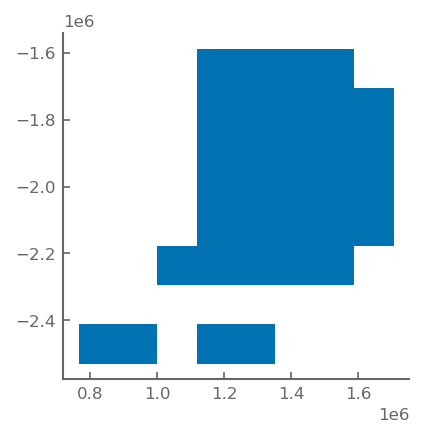

In [16]:
df_.query("(cyclones==203952.0)  & (date=='1988-12-26')").plot()

In [ ]:
df_blob_cycs = pd.DataFrame(df_.groupby(['cyclones', 'date','time_of_event']).agg(dict(attributions='sum',
                                                                    #    time_of_event='first',
                                                                       timestep_past='first',
                                                                       segment_size='sum')))
categories = np.array(['                     ' for k in df_blob_cycs.index])
categories[((df_blob_cycs.segment_size<0.1e7)).values] = 'small blob'
categories[((np.abs(df_blob_cycs.attributions)<.1)&(df_blob_cycs.segment_size>0.1e7)).values] = 'large neutral'
categories[((df_blob_cycs.attributions<-.1)&(df_blob_cycs.segment_size>0.1e7)).values] = 'large negative'
categories[((df_blob_cycs.attributions>.1)&(df_blob_cycs.segment_size>0.1e7)).values] = 'large positive'
df_blob_cycs['category'] = categories
df_blob_cycs['key'] = (df_blob_cycs.reset_index().date.dt.strftime("%Y-%m-%d") + ' '+df_blob_cycs.reset_index().cyclones.astype(str)).values

daily_cycs_for_blobs = daily_cycs.reset_index().set_index('key').loc[df_blob_cycs.key]
df_blob_cycs[['msl','lon','lat','x','y']] = daily_cycs_for_blobs[['msl','lon','lat','x','y']].values
# df_blob_cycs = pd.concat([daily_cycs.reset_index().set_index(['track_id','date']), df_blob_cycs.reset_index().rename(columns=dict(cyclones='track_id')).set_index(['track_id','date'])],axis=1)
# df_blob_cycs
# df_blob_cycs.groupby(['cyclones', 'date']).segment_size.sum()

In [134]:
df_['segment_size'] = df_.area/1_000_000
df_['is_cyclone'] = df_.cyclones.notnull()
df_['date'] = df_.time_of_event + pd.Timedelta('1D')*df_.timestep_past
categories = np.array(['                     ' for k in df_.index])
categories[((df_.segment_size<0.1e7)).values] = 'small blob'
categories[((np.abs(df_.attributions)<.05)&(df_.segment_size>0.1e7)).values] = 'large neutral'
categories[((df_.attributions<-.05)&(df_.segment_size>0.1e7)).values] = 'large negative'
categories[((df_.attributions>.05)&(df_.segment_size>0.1e7)).values] = 'large positive'
df_['category'] = categories

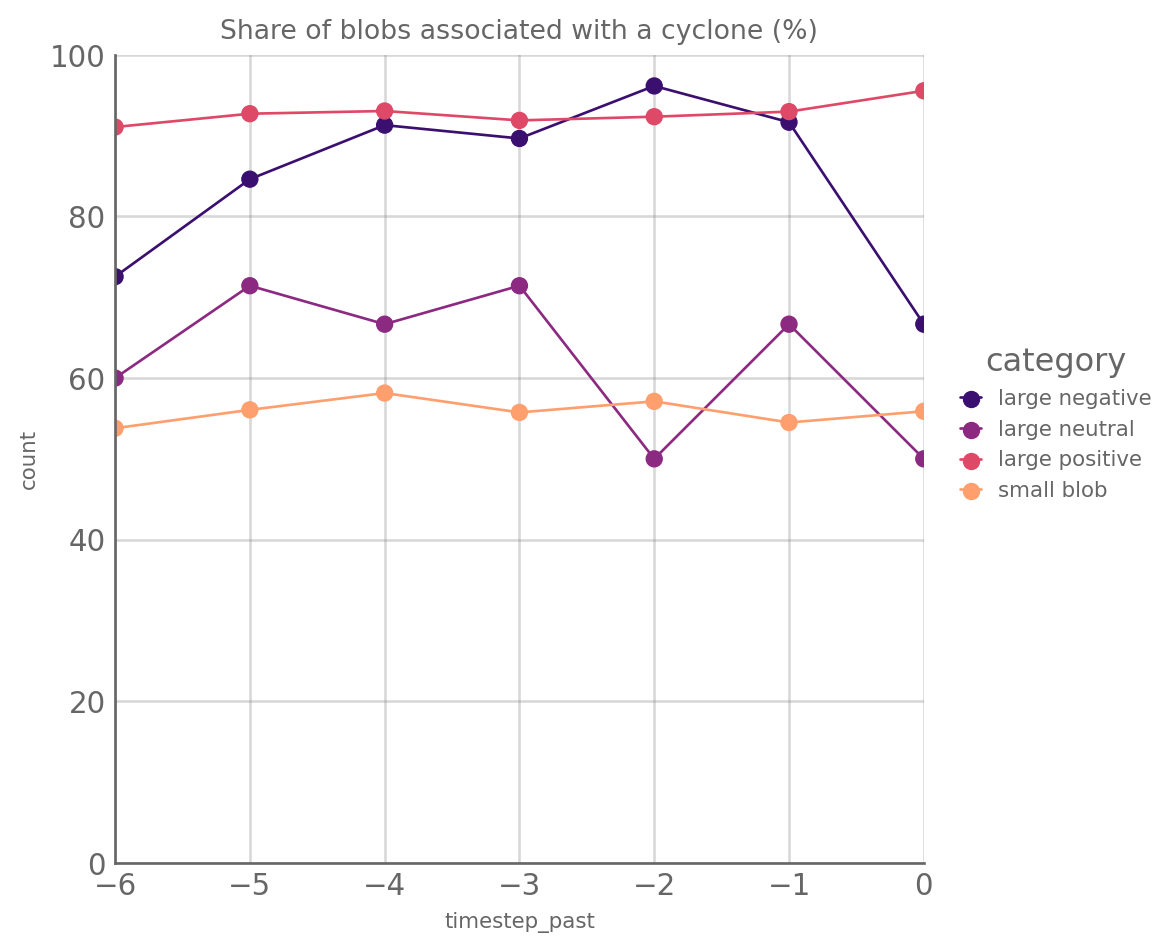

In [20]:
df_plot = (100*df_.query("is_cyclone").groupby(['timestep_past','category']).time_of_event.count().rename('count')/df_.groupby(['timestep_past','category']).time_of_event.count().rename('count')).reset_index()
(so.Plot(df_plot , x='timestep_past', color='category', y='count')
.add(so.Line(), )
.add(so.Dot(), )
 .label(title='Share of blobs associated with a cyclone (%)')
 .layout(size=(5,5))
 .limit(x=(-6,0), y=(0,100))
 .theme(plt.style.library["robin"])
 .scale(color = 'magma')
 .theme({'axes.grid':True, 'grid.color':'.5','grid.linestyle':'-', 'grid.alpha':.3})
)

/tmp/ipykernel_2999143/1233076026.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df__ = df_.groupby(['timestep_past','time_of_event', ]).apply(lambda x:x.query("category=='large positive'").category.size).rename('large positive blob').reset_index()#.groupby(['timestep_past', 'category']).count().reset_index()


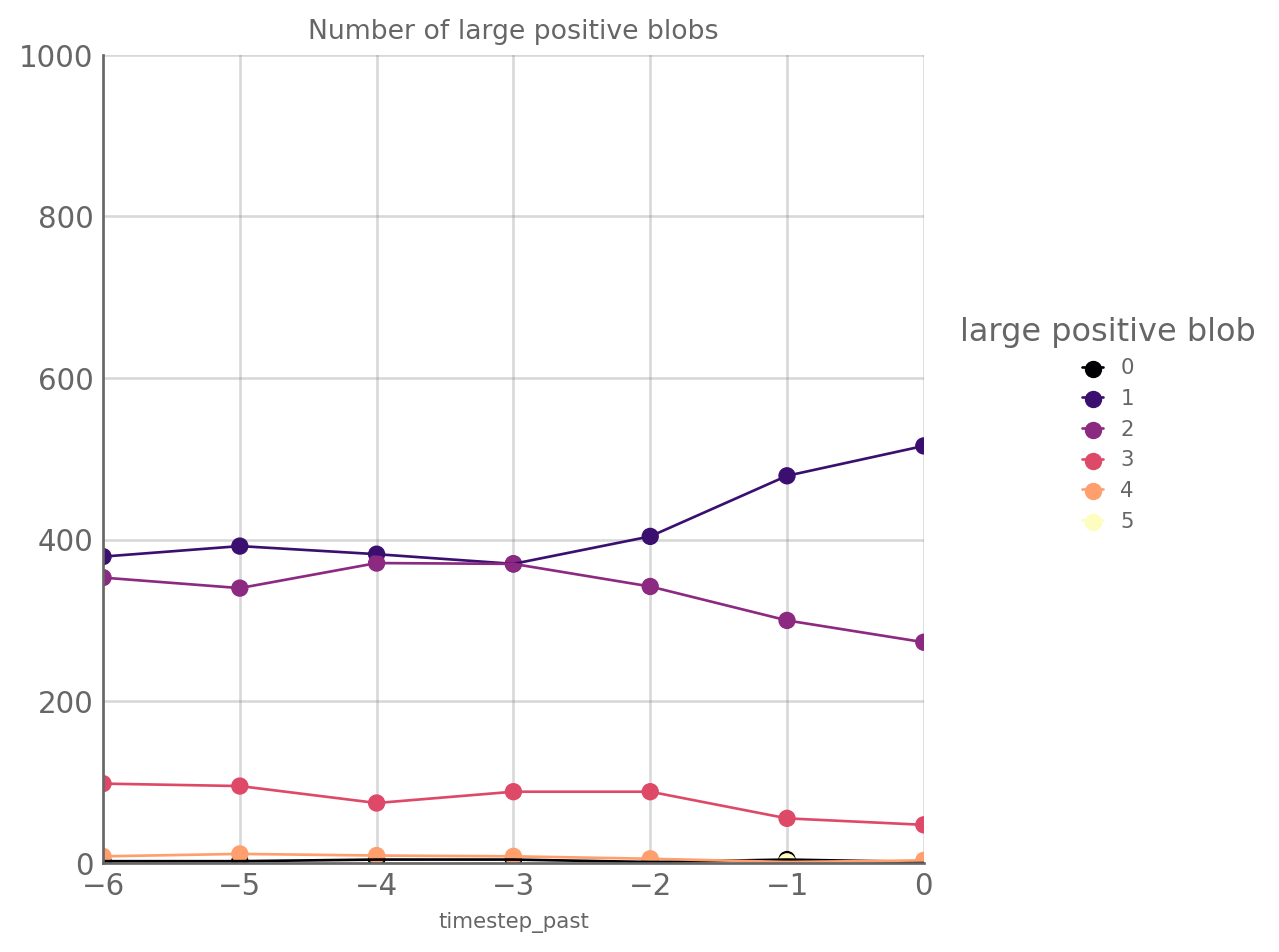

In [21]:
df__ = df_.groupby(['timestep_past','time_of_event', ]).apply(lambda x:x.query("category=='large positive'").category.size).rename('large positive blob').reset_index()#.groupby(['timestep_past', 'category']).count().reset_index()
(so.Plot(df__, x='timestep_past', color='large positive blob')
.add(so.Line(), so.Count())
.add(so.Dot(), so.Count())
 .label(title='Number of large positive blobs')
 .layout(size=(5,5))
 .limit(x=(-6,0), y=(0,1000))
 .theme(plt.style.library["robin"])
 .scale(color = 'magma')
 .theme({'axes.grid':True, 'grid.color':'.5','grid.linestyle':'-', 'grid.alpha':.3})
)
# df__

/tmp/ipykernel_2999143/1602290768.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df__ = df_.groupby(['timestep_past','time_of_event', ]).apply(lambda x:x.query("category=='large positive'").cyclones.count()).rename('cyclone_count').reset_index()


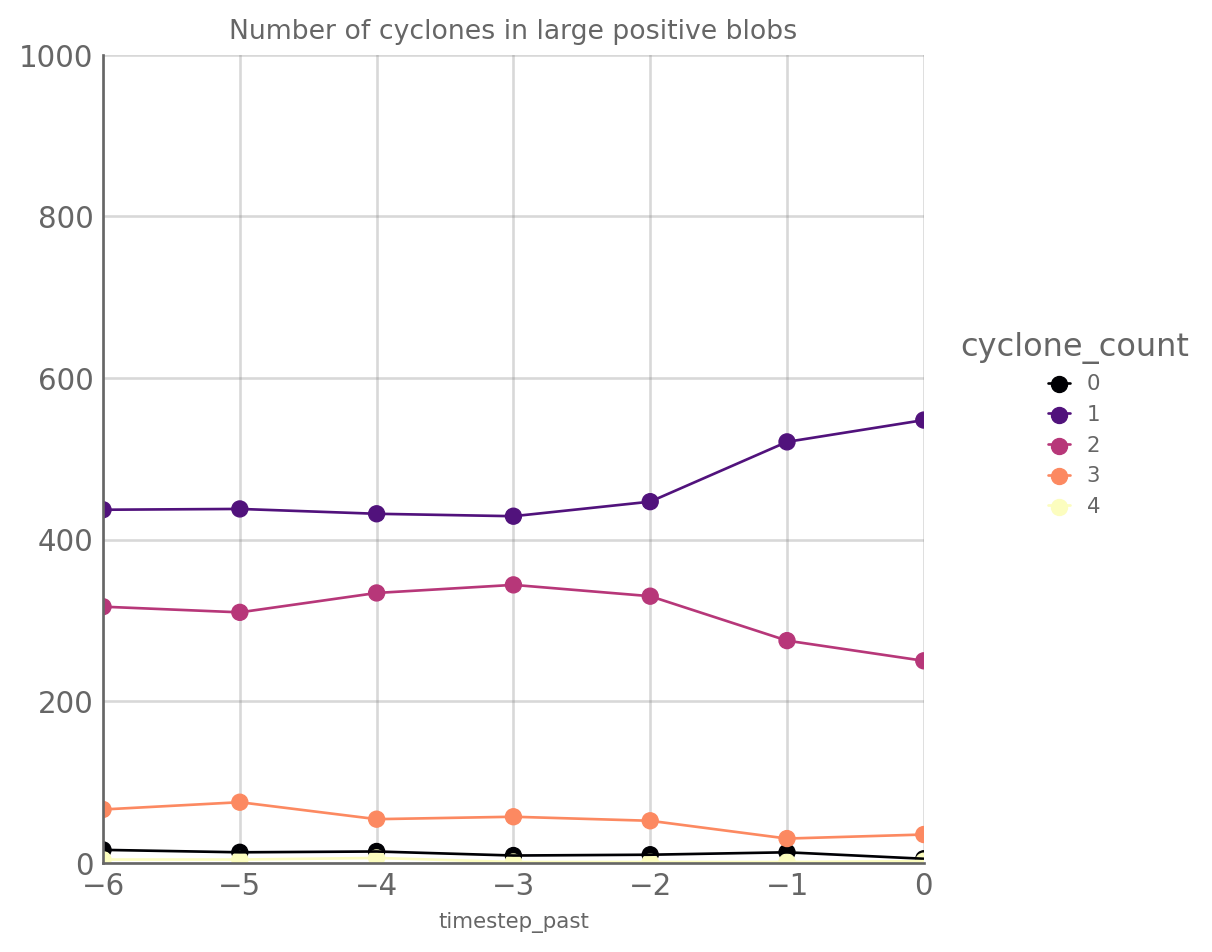

In [22]:
df__ = df_.groupby(['timestep_past','time_of_event', ]).apply(lambda x:x.query("category=='large positive'").cyclones.count()).rename('cyclone_count').reset_index()
(so.Plot(df__, x='timestep_past', color='cyclone_count')
.add(so.Line(), so.Count())
.add(so.Dot(), so.Count())
 .label(title='Number of cyclones in large positive blobs')

 .layout(size=(5,5))
  .limit(x=(-6,0), y=(0,1000))
  .theme(plt.style.library["robin"])
  .scale(color = 'magma')
 .theme({'axes.grid':True, 'grid.color':'.5','grid.linestyle':'-', 'grid.alpha':.3})
)

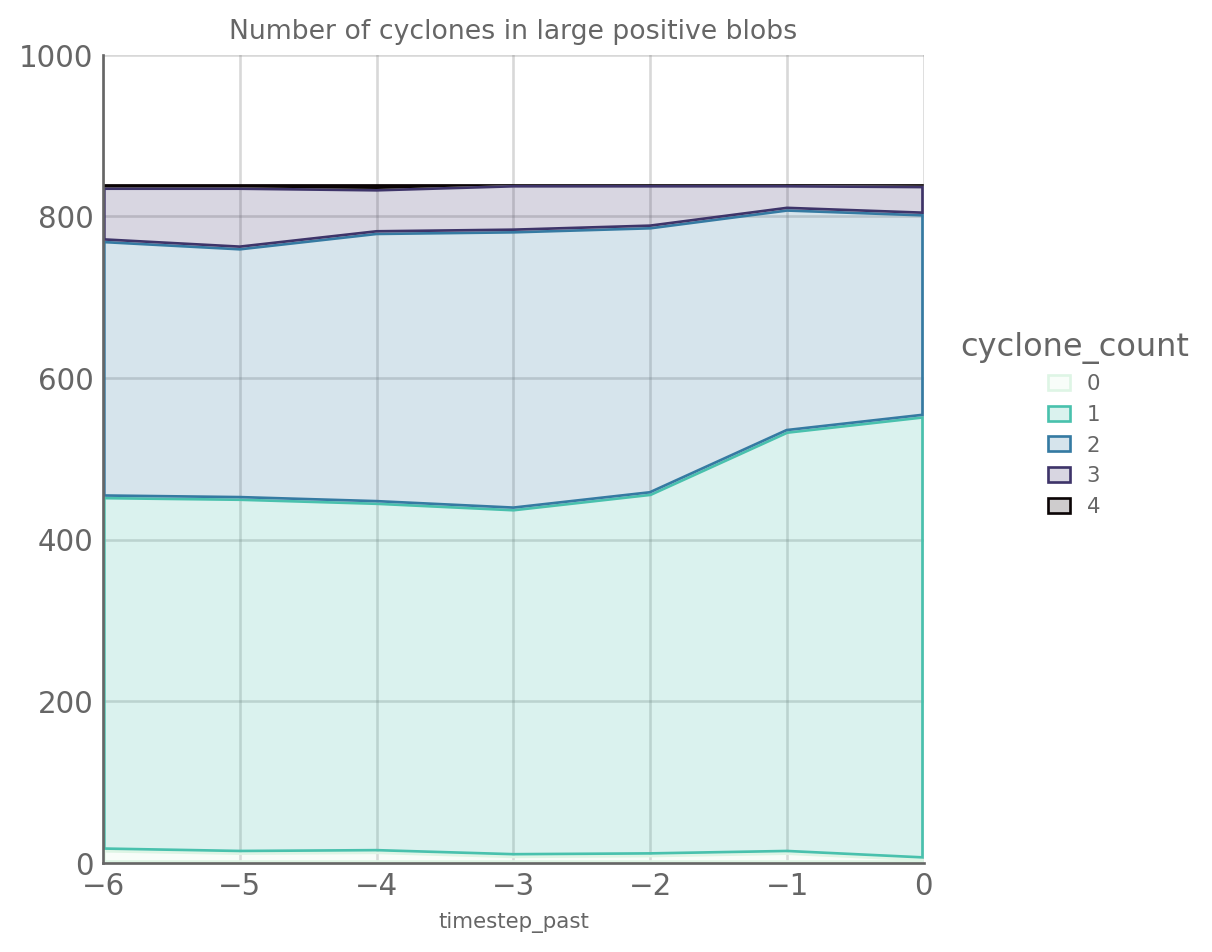

In [23]:
(so.Plot(df__, x='timestep_past', color='cyclone_count')
.add(so.Area(), so.Count(), so.Stack())
# .add(so.Dot(), so.Count())
 .label(title='Number of cyclones in large positive blobs')

 .layout(size=(5,5))
  .limit(x=(-6,0), y=(0,1000))
  .theme(plt.style.library["robin"])
  .scale(color = 'mako_r')
 .theme({'axes.grid':True, 'grid.color':'.5','grid.linestyle':'-', 'grid.alpha':.3})
)

/tmp/ipykernel_2999143/1809370460.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df__ = df_.groupby(['timestep_past','time_of_event', 'is_cyclone']).apply(lambda x:x.query("category=='large positive'").category.size).rename('large positive blob').reset_index()#.groupby(['timestep_past', 'category']).count().reset_index()


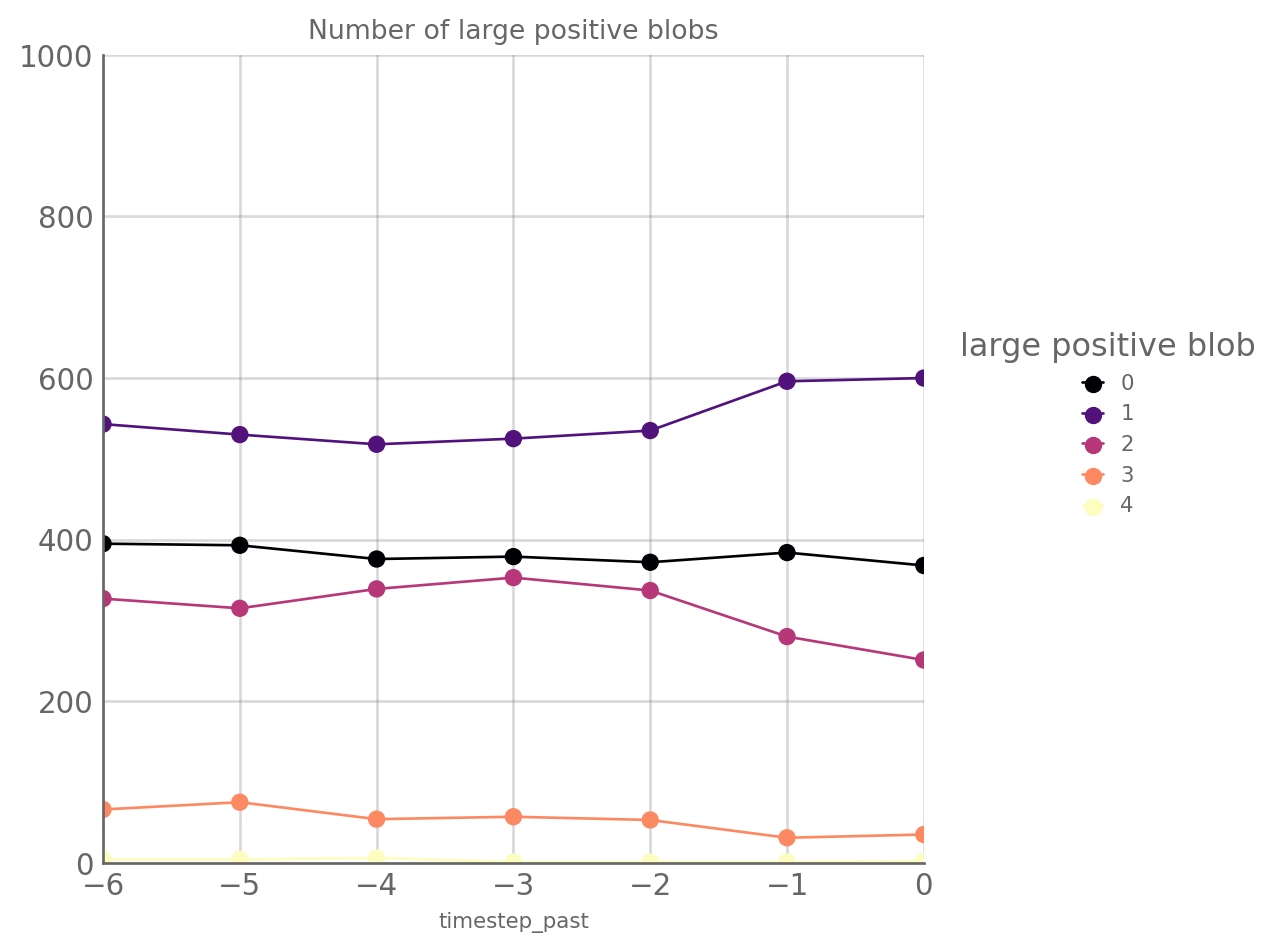

In [24]:
df__ = df_.groupby(['timestep_past','time_of_event', 'is_cyclone']).apply(lambda x:x.query("category=='large positive'").category.size).rename('large positive blob').reset_index()#.groupby(['timestep_past', 'category']).count().reset_index()
(so.Plot(df__, x='timestep_past', color='large positive blob')
.add(so.Line(), so.Count())
.add(so.Dot(), so.Count())
 .label(title='Number of large positive blobs')

 .layout(size=(5,5))
 .limit(x=(-6,0), y=(0,1000))
  .theme(plt.style.library["robin"])
  .scale(color = 'magma')
 .theme({'axes.grid':True, 'grid.color':'.5','grid.linestyle':'-', 'grid.alpha':.3})
)
# df__

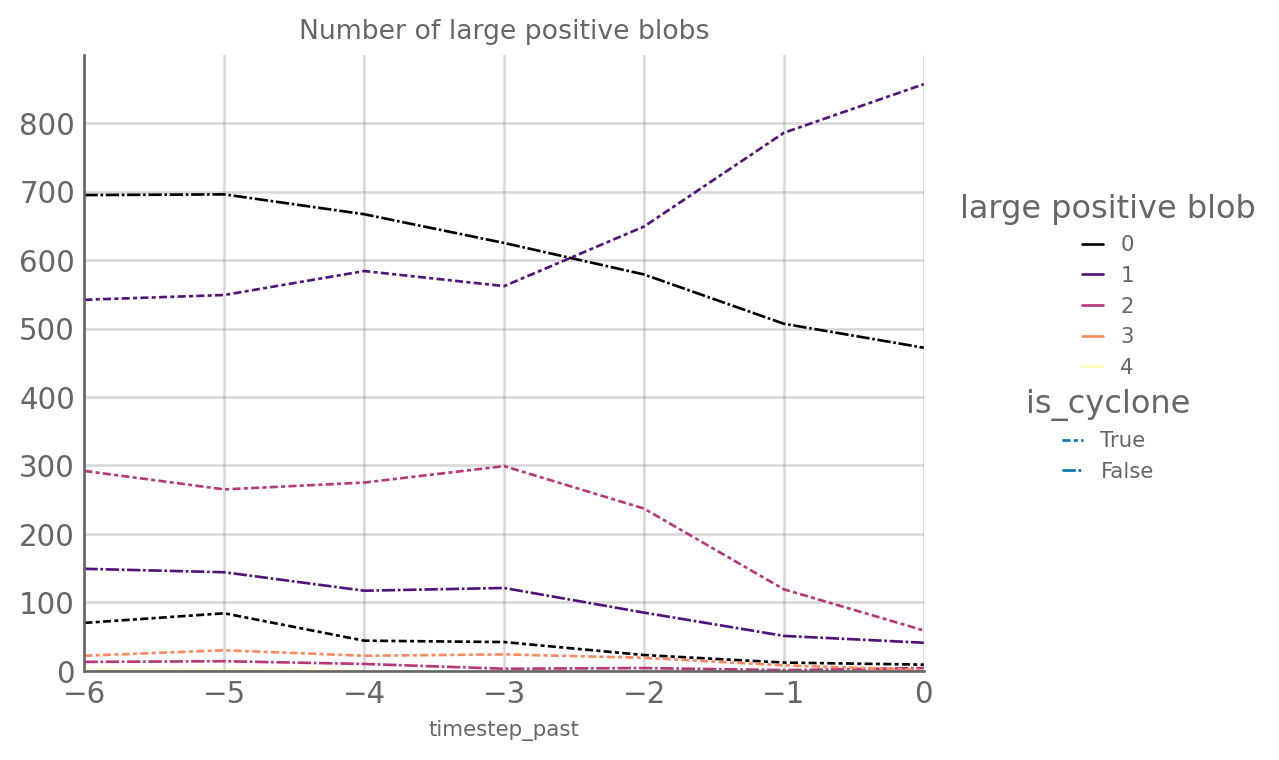

In [904]:
(so.Plot(df__, x='timestep_past', color='large positive blob', linestyle='is_cyclone')
.add(so.Line(), so.Count())
# .add(so.Dot(), so.Count())
 .label(title='Number of large positive blobs')

 .layout(size=(5,4))
 .limit(x=(-6,0), y=(0,None))
  .theme(plt.style.library["robin"])
  .scale(color = 'magma')
 .theme({'axes.grid':True, 'grid.color':'.5','grid.linestyle':'-', 'grid.alpha':.3})
)


In [628]:
df_['segment_size'] = df_.area/1_000_000
df_['is_cyclone'] = df_.cyclones.notnull()
df_['date'] = df_.time_of_event + pd.Timedelta('1D')*df_.timestep_past
categories = np.array(['                     ' for k in df_.index])
categories[((df_.segment_size<0.1e7)).values] = 'small blob'
categories[((np.abs(df_.attributions)<.1)&(df_.segment_size>0.1e7)).values] = 'large neutral'
categories[((df_.attributions<-.1)&(df_.segment_size>0.1e7)).values] = 'large negative'
categories[((df_.attributions>.1)&(df_.segment_size>0.1e7)).values] = 'large positive'
df_['category'] = categories

## Blobs distributions

KeyboardInterrupt: 

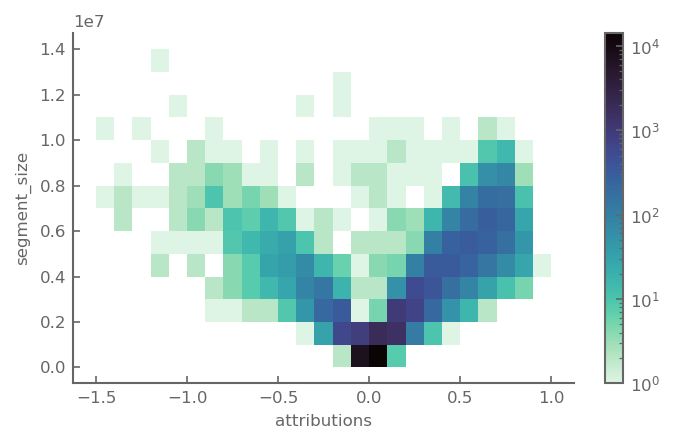

In [589]:
plot = sns.displot(df_, x = 'attributions', y ='segment_size', norm=LogNorm(), cmap='mako_r', vmin=None, vmax=None, 
                   bins=[np.arange(-1.5,1.1,.1), np.arange(0,1.5,.1)*1e7], 
                   cbar = True, aspect=1.6, height=3)
ax = plot.axes[0,0]
ax.set_xlim(-1.5,1)
ax.set_ylim(0,1.4e7)
ax.grid()

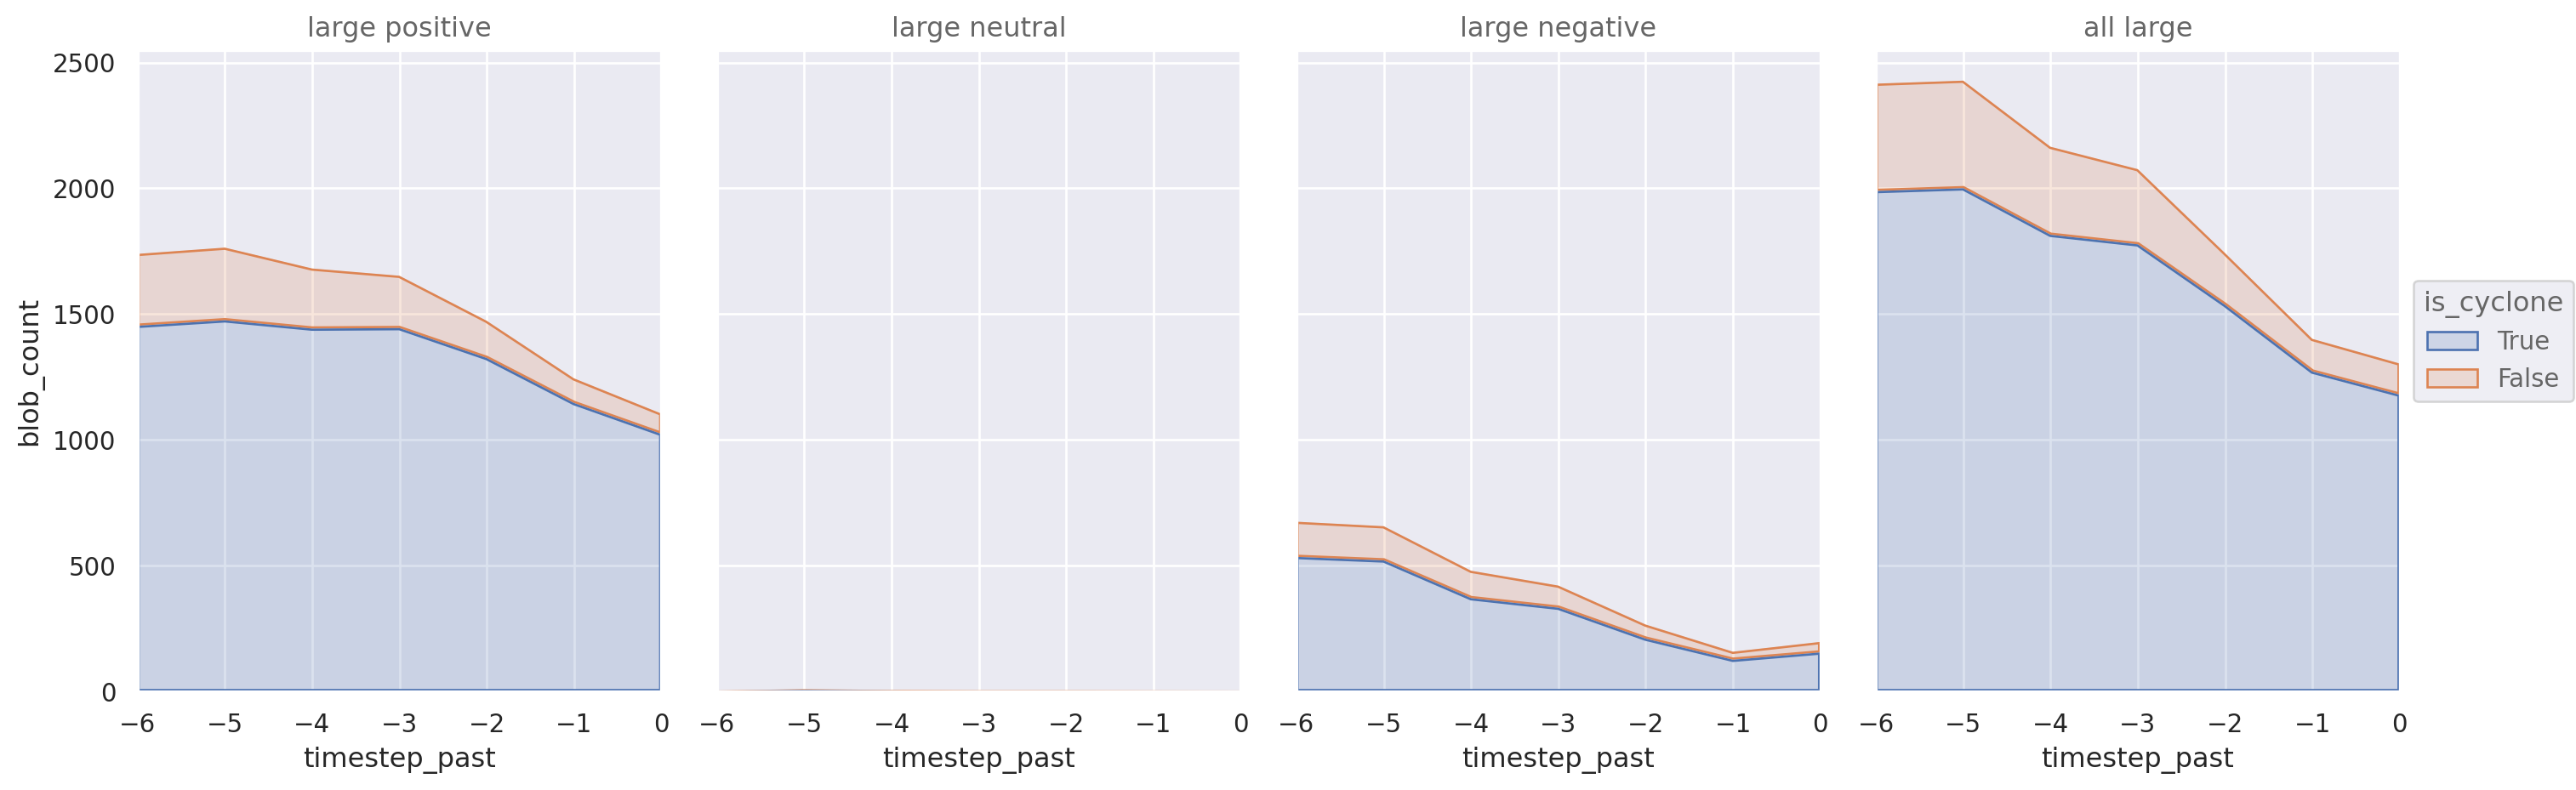

In [958]:
df_counts = df_.query("segment_size>.1e7").groupby(['category', 'is_cyclone','timestep_past']).geometry.count().rename('blob_count').reset_index()[::-1]
df_counts_all = df_.query("segment_size>.1e7").groupby([ 'is_cyclone','timestep_past']).geometry.count().rename('blob_count').reset_index()[::-1]
df_counts_all['category'] = 'all large'
df_counts = pd.concat([df_counts,df_counts_all])
df_counts
(so.Plot(df_counts, x='timestep_past', color='is_cyclone', y='blob_count')
 .add(so.Area(), so.Stack(), )
 .scale(col=so.Nominal(order=['large positive', 'large negative', 'large neutral', 'small blobs']))
#  .scale(stack=so.Nominal(order=[True, False]))
 .layout(size=(15,5))
 .facet(col='category')
#  .share(y=False)
 .limit(x=(-6,0), y=(0,None))
 
)


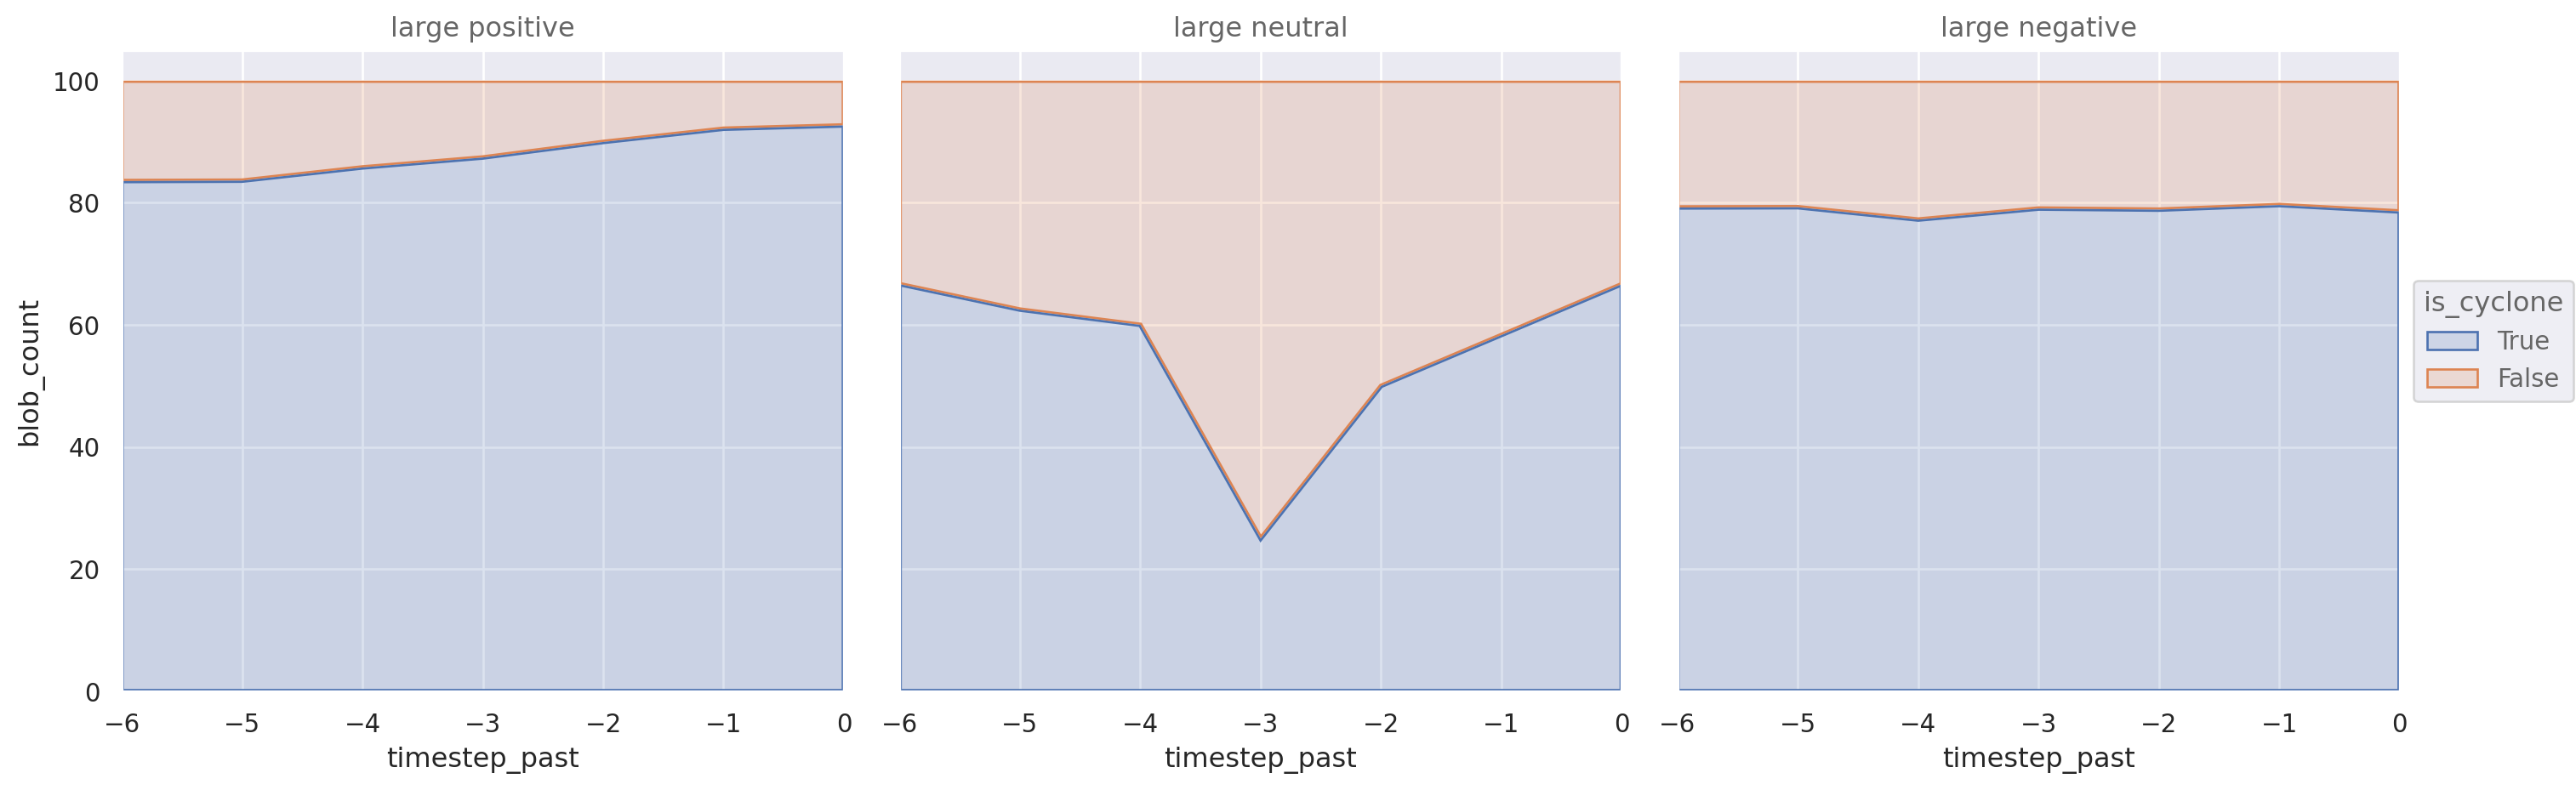

In [959]:
df_counts = df_.query("segment_size>.1e7").groupby(['category', 'is_cyclone','timestep_past']).geometry.count().rename('blob_count')
df_counts_all = df_.query("segment_size>.1e7").groupby(['category','timestep_past']).geometry.count().rename('blob_count')
# df_counts_all['category'] = 'all large'
df_counts=100*df_counts/df_counts_all
df_counts
(so.Plot(df_counts.reset_index()[::-1], x='timestep_past', color='is_cyclone', y='blob_count')
 .add(so.Area(), so.Stack(), )
 .scale(col=so.Nominal(order=['large positive', 'large negative', 'large neutral', 'small blobs']))
 .scale(stack=so.Nominal(order=[False, True]))
 .layout(size=(15,5))
 .facet(col='category')
#  .share(y=False)
 .limit(x=(-6,0), y=(0,None))
 
)


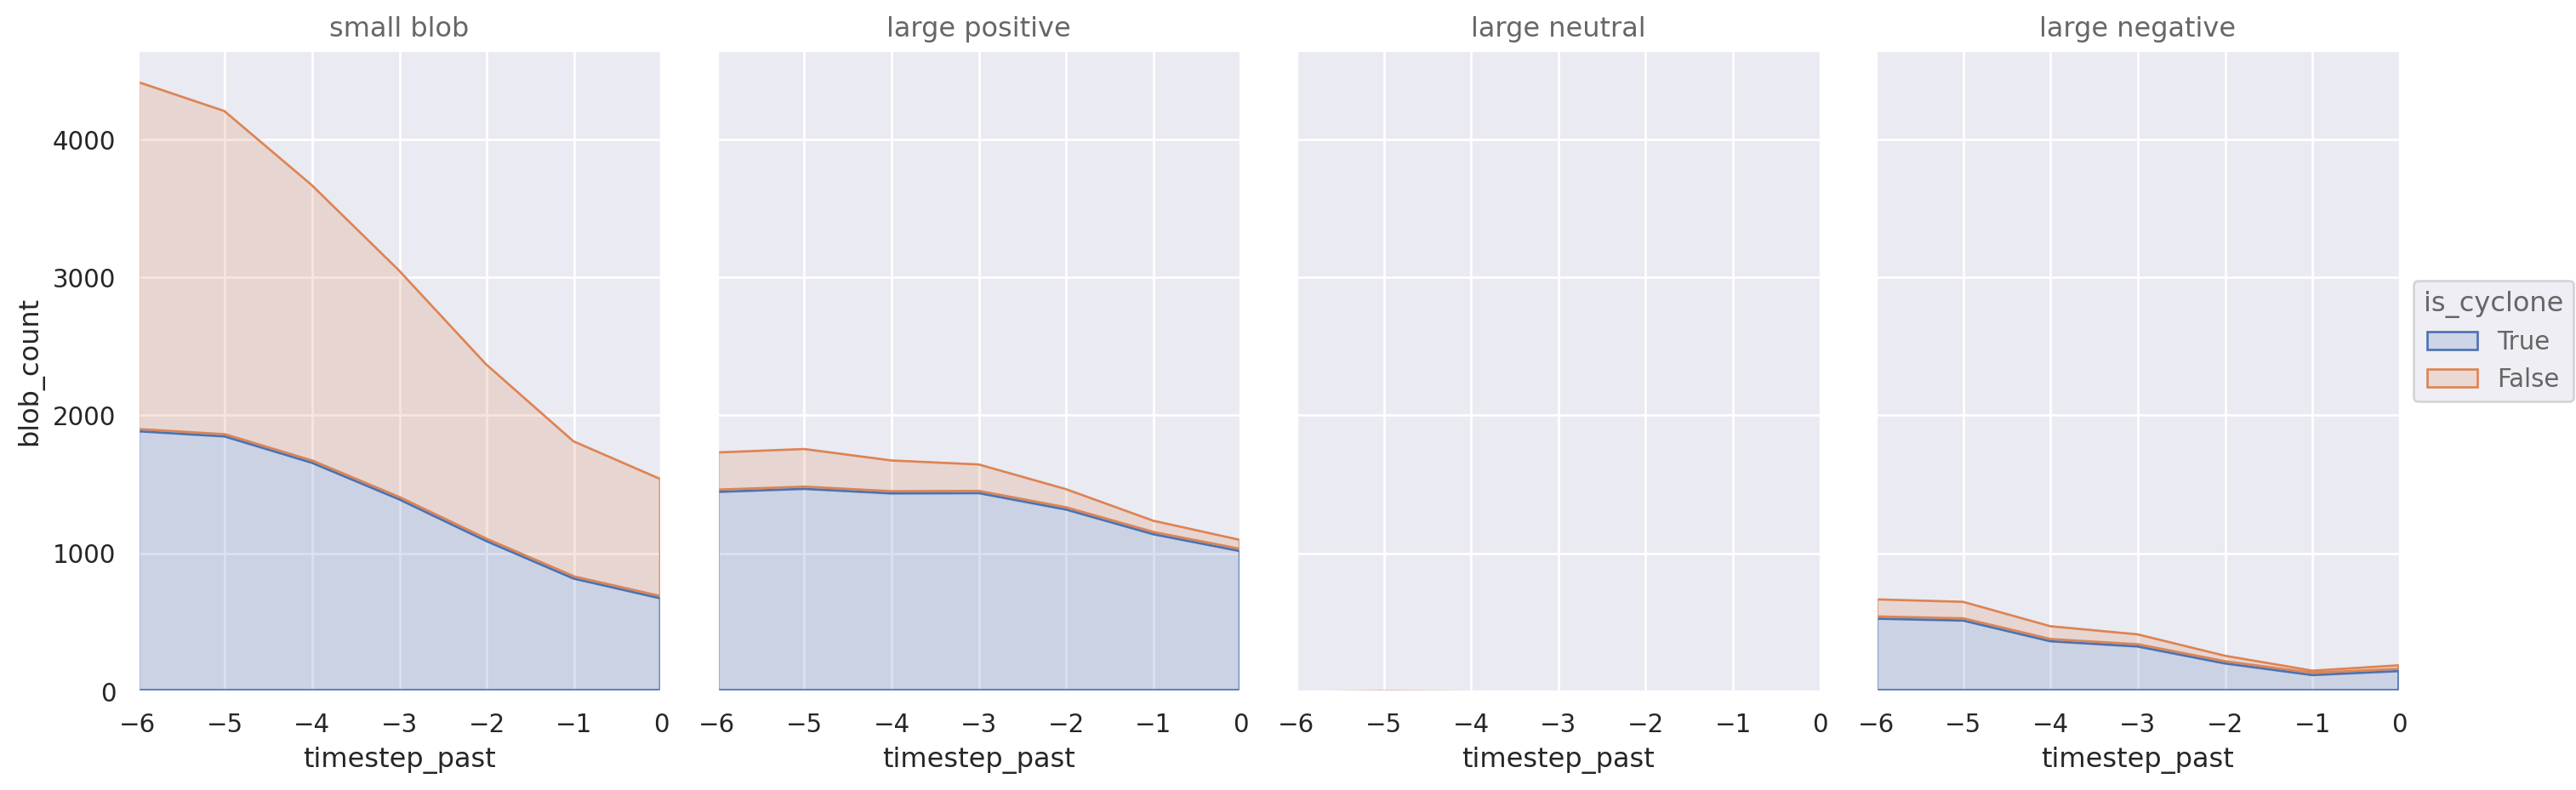

In [960]:
df__ = df_.groupby(['category', 'is_cyclone','timestep_past']).geometry.count().rename('blob_count').reset_index()[::-1]
# df__['category'] = ['Small negative']*2 + ['Large negative']*2 +['Small neutral']*2+['Large neutral']*2+['Small positive']*2+['Large positive']*2
(so.Plot(df__, x='timestep_past', color='is_cyclone', y='blob_count')
 .add(so.Area(), so.Stack(), )
 .scale(col=so.Nominal(order=['large positive', 'large negative', 'large neutral', 'small blobs']))
#  .scale(stack=so.Nominal(order=[True, False]))
 .layout(size=(15,5))
 .facet(col='category')
#  .share(y=False)
 .limit(x=(-6,0), y=(0,None))
 
)

# df__

/tmp/ipykernel_59320/2584833716.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_counts = df_.query("category!='small blob'").groupby([pd.cut(df_.query("category!='small blob'").attributions, np.arange(-1.5,1.1,.1)),'is_cyclone', 'timestep_past']).geometry.count().rename('blob_count').reset_index()[::-1]


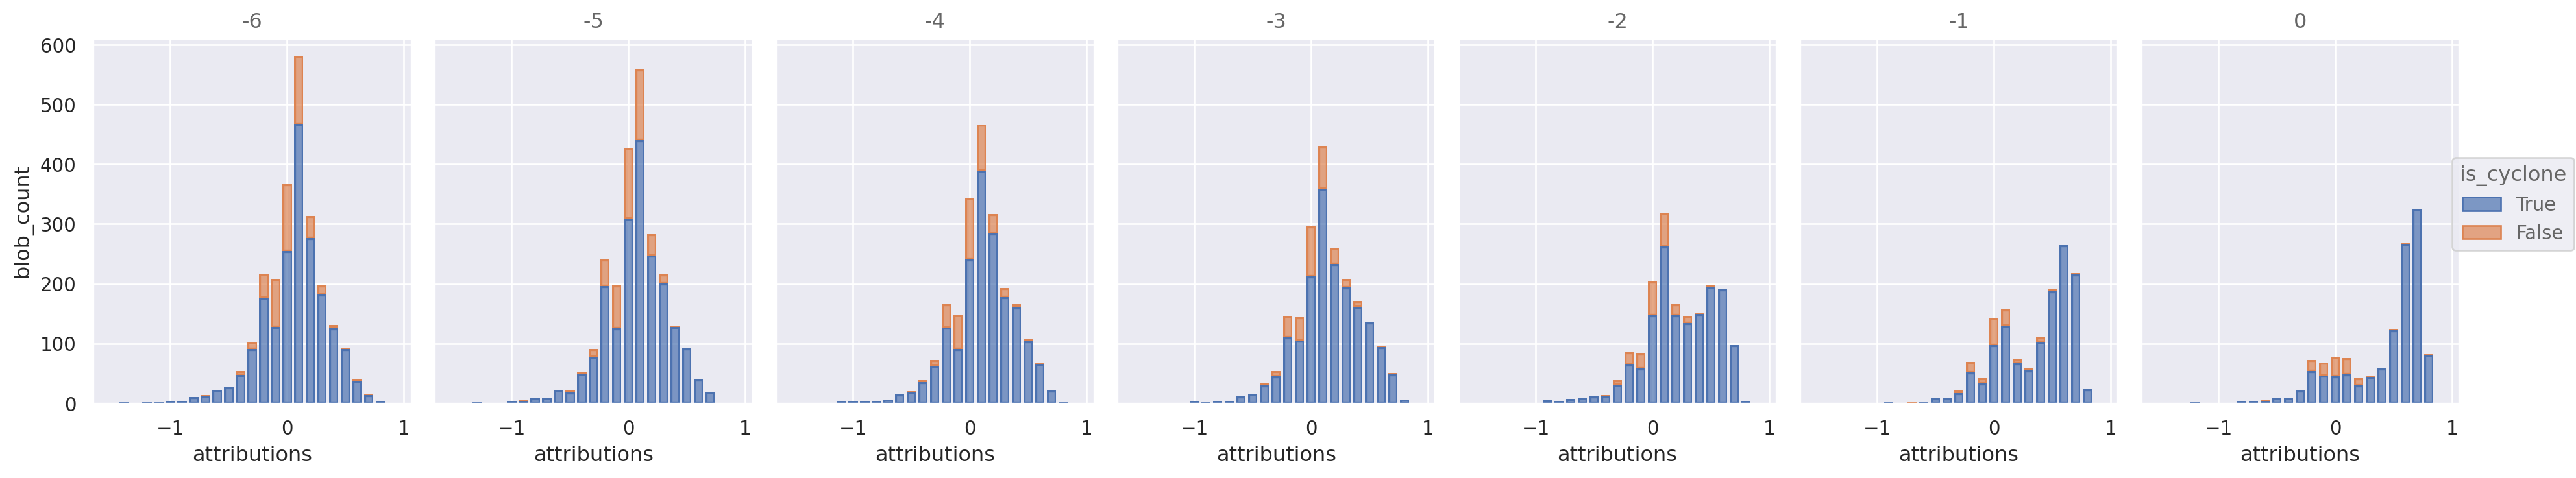

In [631]:
df_counts = df_.query("category!='small blob'").groupby([pd.cut(df_.query("category!='small blob'").attributions, np.arange(-1.5,1.1,.1)),'is_cyclone', 'timestep_past']).geometry.count().rename('blob_count').reset_index()[::-1]
df_counts['attributions'] = [k.left for k in df_counts.attributions]
(so.Plot(df_counts,color='is_cyclone',
         y='blob_count',
         x='attributions')
         .add(so.Bar(), so.Stack())
         .facet(col='timestep_past')
         .layout(size=(20,4))
 
 )

In [961]:
df_blob_cycs = pd.DataFrame(df_.groupby(['cyclones', 'date','time_of_event']).agg(dict(attributions='sum',
                                                                    #    time_of_event='first',
                                                                       timestep_past='first',
                                                                       segment_size='sum')))
categories = np.array(['                     ' for k in df_blob_cycs.index])
categories[((df_blob_cycs.segment_size<0.1e7)).values] = 'small blob'
categories[((np.abs(df_blob_cycs.attributions)<.1)&(df_blob_cycs.segment_size>0.1e7)).values] = 'large neutral'
categories[((df_blob_cycs.attributions<-.1)&(df_blob_cycs.segment_size>0.1e7)).values] = 'large negative'
categories[((df_blob_cycs.attributions>.1)&(df_blob_cycs.segment_size>0.1e7)).values] = 'large positive'
df_blob_cycs['category'] = categories
df_blob_cycs['key'] = (df_blob_cycs.reset_index().date.dt.strftime("%Y-%m-%d") + ' '+df_blob_cycs.reset_index().cyclones.astype(str)).values

daily_cycs_for_blobs = daily_cycs.reset_index().set_index('key').loc[df_blob_cycs.key]
df_blob_cycs[['msl','lon','lat','x','y']] = daily_cycs_for_blobs[['msl','lon','lat','x','y']].values
# df_blob_cycs = pd.concat([daily_cycs.reset_index().set_index(['track_id','date']), df_blob_cycs.reset_index().rename(columns=dict(cyclones='track_id')).set_index(['track_id','date'])],axis=1)
# df_blob_cycs
# df_blob_cycs.groupby(['cyclones', 'date']).segment_size.sum()

In [962]:

space = np.array(['                     ' for k in df_blob_cycs.index])
space[((df_blob_cycs.lat>30)&(df_blob_cycs.lon<40)&(df_blob_cycs.lon>-20)).values] = 'Atlantic North East'
space[((df_blob_cycs.lat>30)&(df_blob_cycs.lon<-20)&(df_blob_cycs.lon>-100)).values] = 'Atlantic North West'
space[((df_blob_cycs.lat<60)&((df_blob_cycs.lon<-100)|(df_blob_cycs.lon>120))).values] = 'Pacific'
space[((df_blob_cycs.lat>60)&((df_blob_cycs.lon<-100)|(df_blob_cycs.lon>120))).values] = 'Arctic Pacific'
space[((df_blob_cycs.lat>60)&(df_blob_cycs.lon>40)&(df_blob_cycs.lon<120)).values] = 'Arctic Eurasia'
space[((df_blob_cycs.lat<60)&(df_blob_cycs.lon>40)&(df_blob_cycs.lon<120)).values] = 'Eurasia'

space[((df_blob_cycs.lat<30)&((df_blob_cycs.lon>-100)&(df_blob_cycs.lon<60))).values] = 'Tropical Atlantic'

df_blob_cycs['region'] = space


In [963]:

# space = np.array(['                     ' for k in df_blob_cycs.index])
# space[((df_blob_cycs.lat>30)&(df_blob_cycs.lon<40)&(df_blob_cycs.lon>-10)).values] = 'Atlantic North East'
# space[((df_blob_cycs.lat>30)&(df_blob_cycs.lon<-10)&(df_blob_cycs.lon>-50)).values] = 'Atlantic North Center'
# space[((df_blob_cycs.lat>30)&(df_blob_cycs.lon<-40)&(df_blob_cycs.lon>-100)).values] = 'Atlantic North West'
# space[((df_blob_cycs.lat<60)&((df_blob_cycs.lon<-100)|(df_blob_cycs.lon>120))).values] = 'Pacific'
# space[((df_blob_cycs.lat>60)&((df_blob_cycs.lon<-100)|(df_blob_cycs.lon>120))).values] = 'Arctic Pacific'
# space[((df_blob_cycs.lat>60)&(df_blob_cycs.lon>40)&(df_blob_cycs.lon<120)).values] = 'Arctic Eurasia'
# space[((df_blob_cycs.lat<60)&(df_blob_cycs.lon>40)&(df_blob_cycs.lon<120)).values] = 'Eurasia'

# space[((df_blob_cycs.lat<30)&((df_blob_cycs.lon>-100)&(df_blob_cycs.lon<60))).values] = 'Tropical Atlantic'

# df_blob_cycs['region'] = space


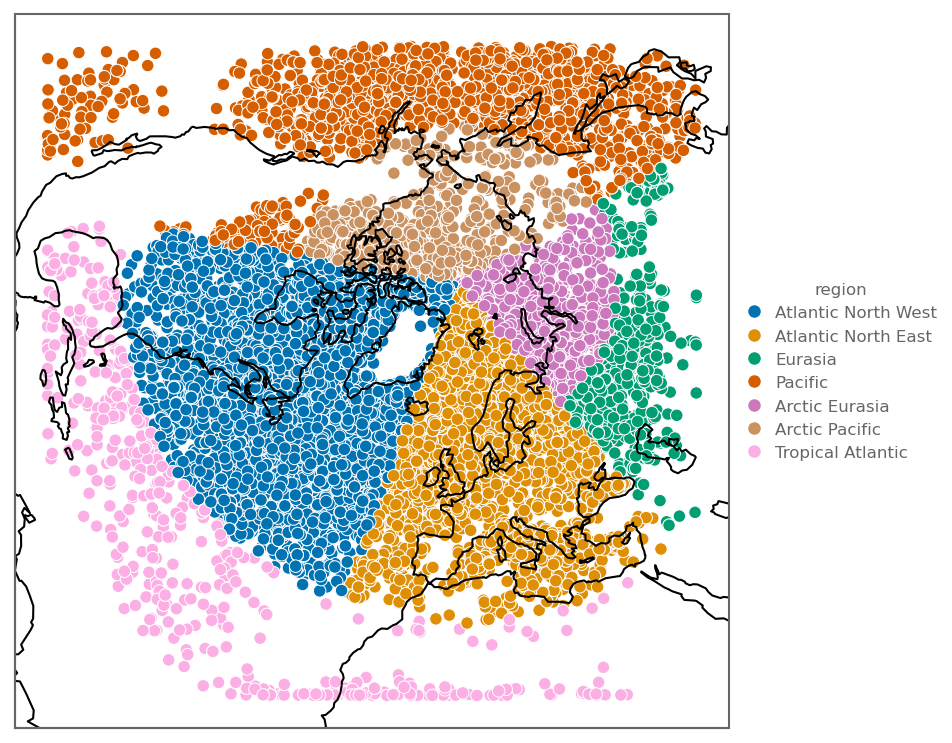

In [964]:
plot = sns.relplot(df_blob_cycs.dropna(), x='x', y='y', hue='region',  hue_order=['Atlantic North West','Atlantic North East',
       'Eurasia', 'Pacific', 'Arctic Eurasia','Arctic Pacific', 
       'Tropical Atlantic'], facet_kws=dict(subplot_kws=dict(projection=proj)))

plot.axes[0,0].coastlines()

/tmp/ipykernel_59320/3376142506.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_cycs = df_blob_cycs.reset_index().set_index('cyclones').groupby(['timestep_past','time_of_event']).apply(lambda x:x.loc[x.attributions.idxmax()].region).rename('region').reset_index()
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/seaborn/_core/moves.py:256: FutureWarning: using <function <lambda> at 0x7fe872ec6340> in Series.agg cannot aggregate and has been deprecated. Use Series.transform to keep behavior unchanged.
  df[var] = df[var] / denom_data.agg(self.func)
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/seaborn/_core/moves.py:256: FutureWarning: u

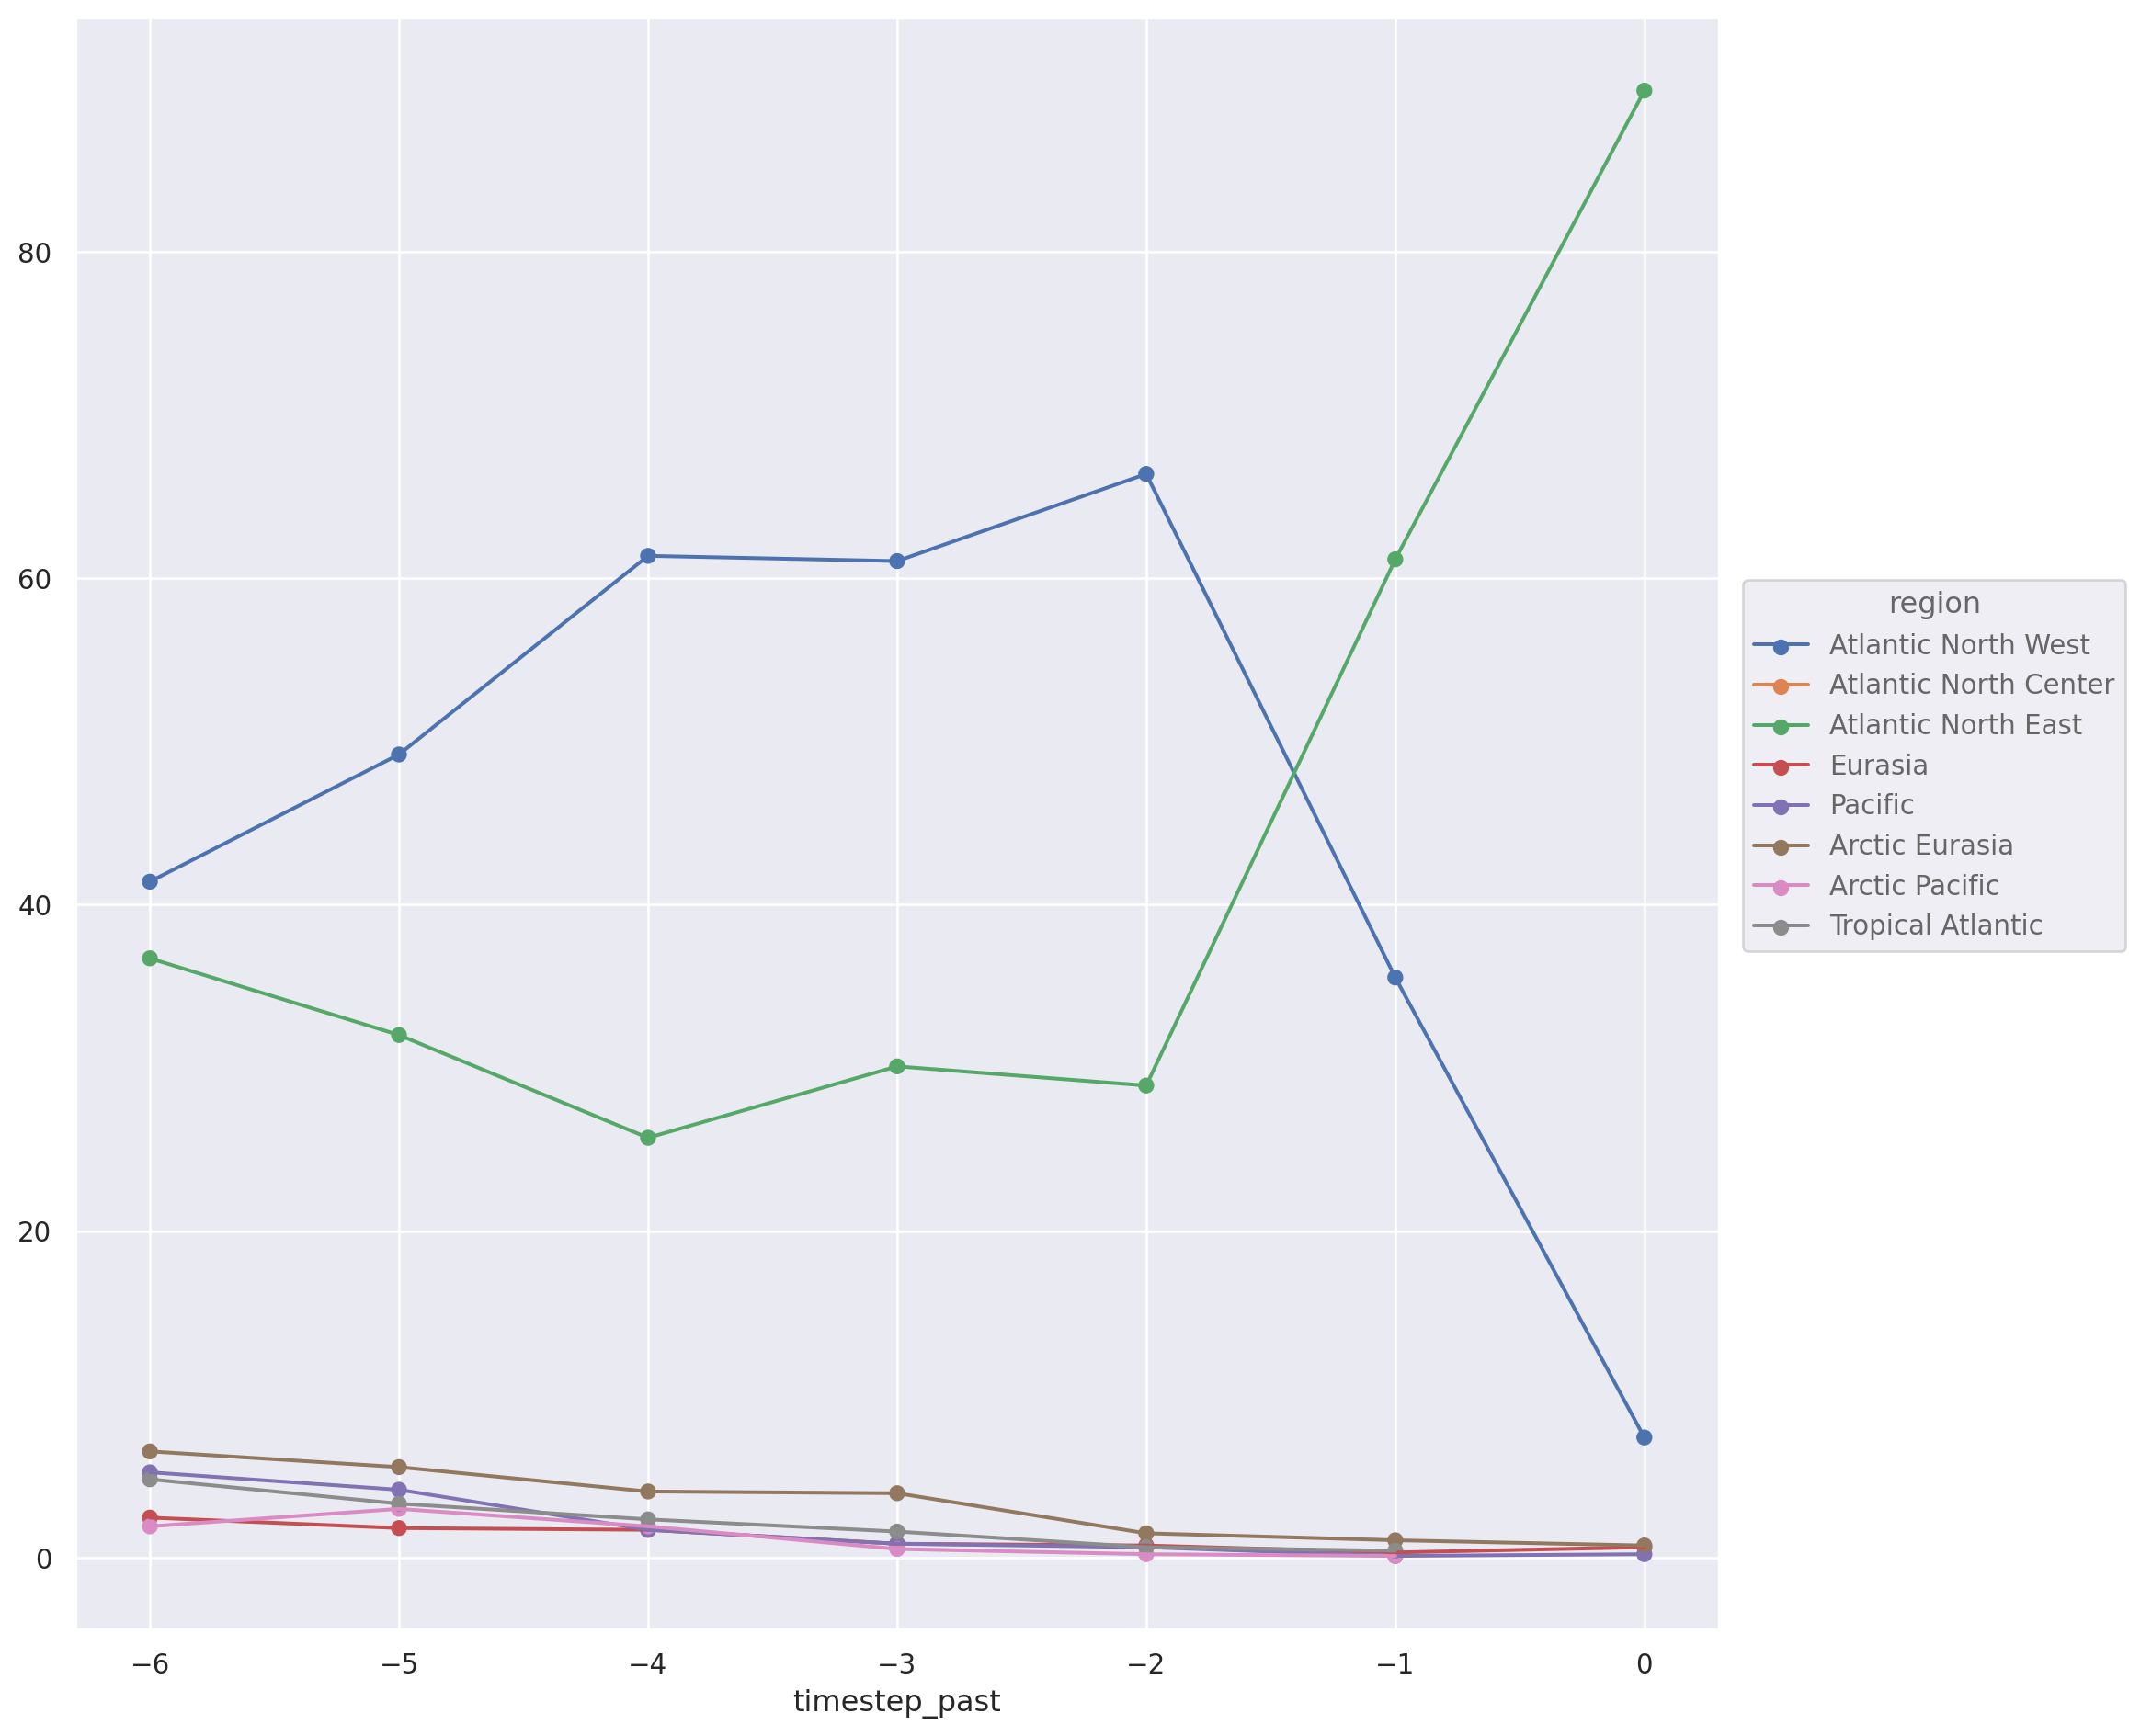

In [965]:
top_cycs = df_blob_cycs.reset_index().set_index('cyclones').groupby(['timestep_past','time_of_event']).apply(lambda x:x.loc[x.attributions.idxmax()].region).rename('region').reset_index()
top_cycs

(so.Plot(top_cycs, x='timestep_past', color='region')
 .add(so.Line(), so.Count(), so.Norm(func=lambda x:937, percent=True))
 .add(so.Dot(), so.Count(), so.Norm(func=lambda x:937, percent=True))
#  .facet(col='category')
 .scale(color=so.Nominal(order=['Atlantic North West', 'Atlantic North Center' ,'Atlantic North East',
       'Eurasia', 'Pacific', 'Arctic Eurasia','Arctic Pacific', 
       'Tropical Atlantic']))

 .layout(size=(10,10))
 )

/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/seaborn/_core/moves.py:256: FutureWarning: using <function <lambda> at 0x7fe88946fba0> in Series.agg cannot aggregate and has been deprecated. Use Series.transform to keep behavior unchanged.
  df[var] = df[var] / denom_data.agg(self.func)
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/seaborn/_core/moves.py:256: FutureWarning: using <function <lambda> at 0x7fe88946e340> in Series.agg cannot aggregate and has been deprecated. Use Series.transform to keep behavior unchanged.
  df[var] = df[var] / denom_data.agg(self.func)


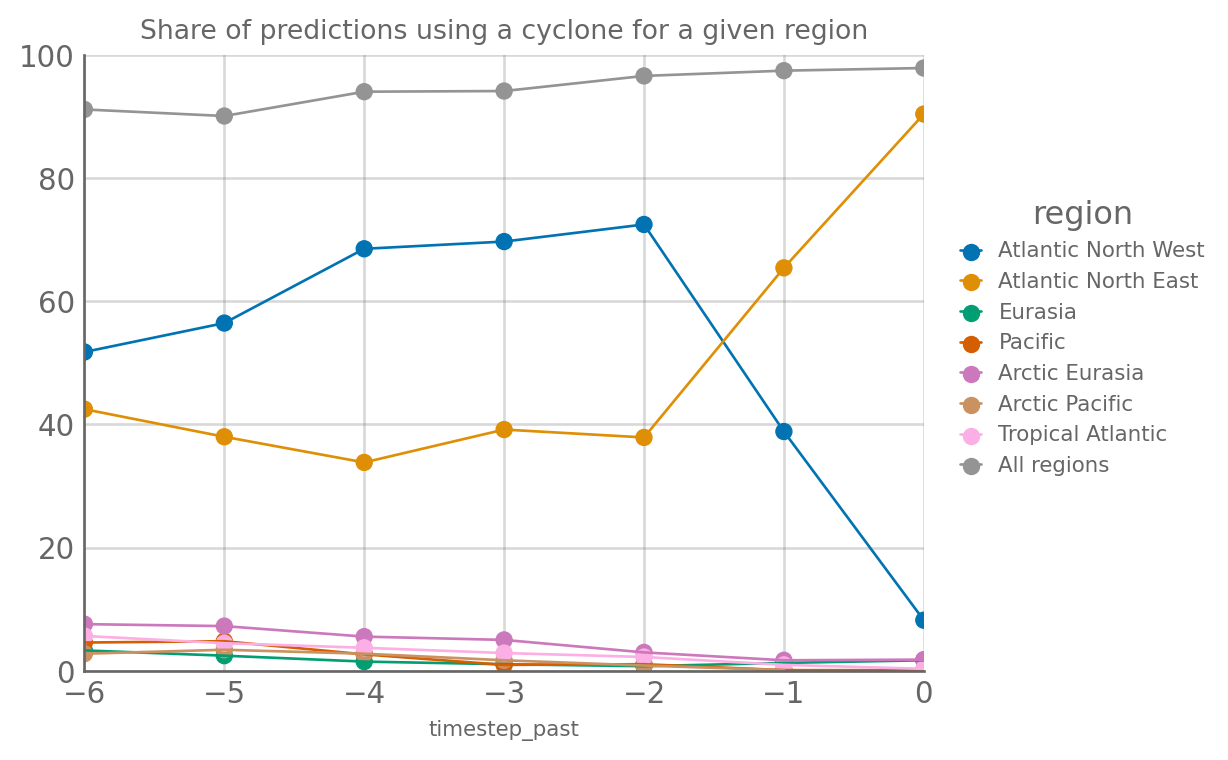

In [966]:
df_counts = df_blob_cycs.reset_index().query("category=='large positive'").groupby(['time_of_event','timestep_past','region']).msl.count().reset_index()
df_all_counts = df_blob_cycs.reset_index().query("category=='large positive'").groupby(['time_of_event','timestep_past']).msl.count().reset_index()
df_all_counts['region'] = 'All regions'
df_counts = pd.concat([df_counts, df_all_counts])

(so.Plot(df_counts, x='timestep_past', color='region')
 .add(so.Line(), so.Count(), so.Norm(func=lambda x:937, percent=True))
#  .add(so.Line(linewidth=3), so.Count(), so.Norm(func=lambda x:937, percent=True), data=df_all_counts)
 .add(so.Dot(), so.Count(), so.Norm(func=lambda x:937, percent=True))
#  .facet(col='category')
 .scale(color=so.Nominal(order=['Atlantic North West','Atlantic North East',
       'Eurasia', 'Pacific', 'Arctic Eurasia','Arctic Pacific', 
       'Tropical Atlantic','All regions']))

 .layout(size=(5,4))
 .limit(x=(-6,0), y=(0,100))
 .label(title='Share of predictions using a cyclone for a given region', )
  .theme(plt.style.library["robin"])
 .theme({'axes.grid':True, 'grid.color':'.5','grid.linestyle':'-', 'grid.alpha':.3})
 )



/tmp/ipykernel_59320/719375370.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df__ = df_.groupby(['timestep_past','time_of_event']).apply(lambda x:x.loc[x.attributions.idxmax()][['is_cyclone','category']]).reset_index().groupby(['timestep_past', 'is_cyclone']).count().reset_index()


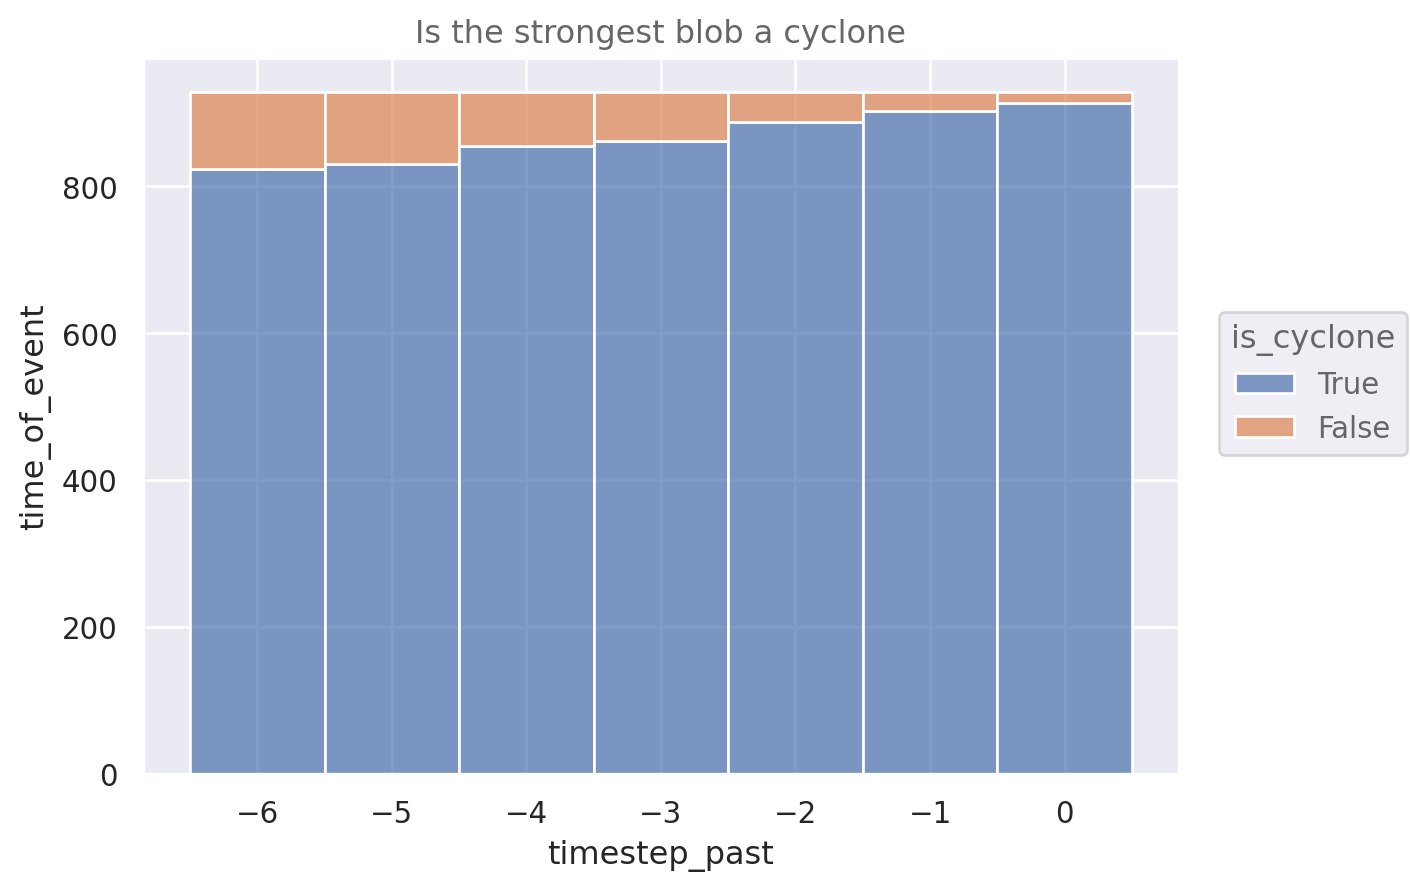

In [967]:
df__ = df_.groupby(['timestep_past','time_of_event']).apply(lambda x:x.loc[x.attributions.idxmax()][['is_cyclone','category']]).reset_index().groupby(['timestep_past', 'is_cyclone']).count().reset_index()
(so.Plot(df__[::-1], x='timestep_past',y='time_of_event', color='is_cyclone')
.add(so.Bars(), so.Stack())
 .label(title='Is the strongest blob a cyclone')
)
# df__

In [777]:
df__

,timestep_past,category,time_of_event,is_cyclone
0,-6,large neutral,12,12
1,-6,large positive,909,909
2,-6,small blob,7,7
3,-5,large neutral,20,20
4,-5,large positive,901,901
5,-5,small blob,7,7
6,-4,large neutral,12,12
7,-4,large positive,913,913
8,-4,small blob,3,3
9,-3,large neutral,7,7


In [782]:
df__

,timestep_past,time_of_event,0
0,-6,1979-01-07,True
1,-6,1979-03-03,True
2,-6,1979-03-04,True
3,-6,1979-03-05,True
4,-6,1979-08-14,True
...,...,...,...
6491,0,2024-12-01,True
6492,0,2024-12-13,True
6493,0,2024-12-15,True
6494,0,2024-12-18,True


/tmp/ipykernel_59320/4005065797.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df__ = df_.groupby(['timestep_past','time_of_event']).apply(lambda x:'large positive' in x.category.values).rename('large positive blob').reset_index()#.groupby(['timestep_past', 'category']).count().reset_index()


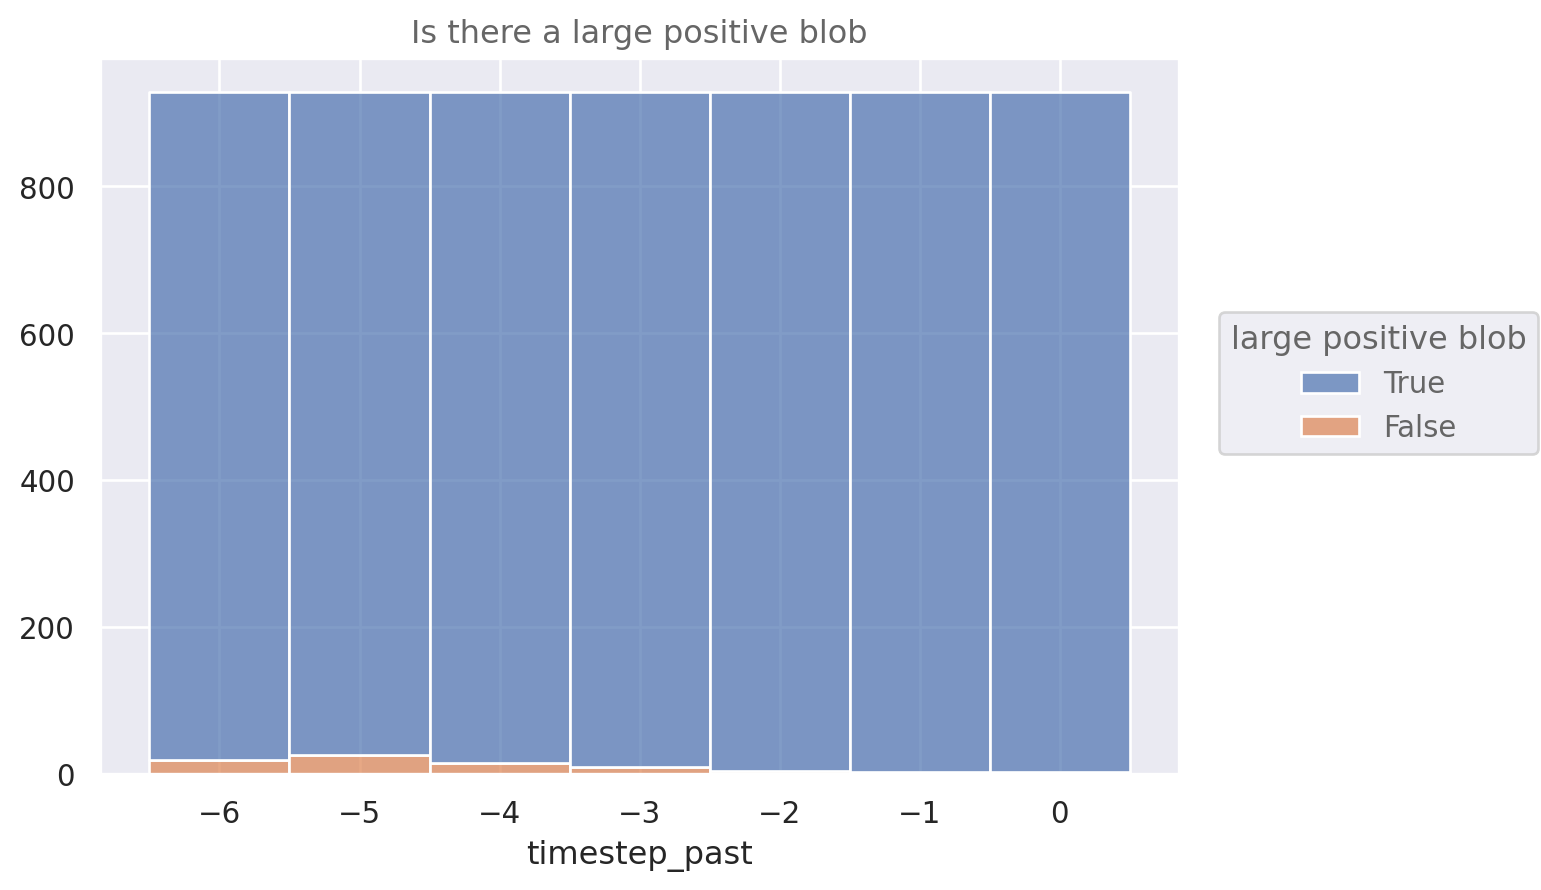

In [788]:
df__ = df_.groupby(['timestep_past','time_of_event']).apply(lambda x:'large positive' in x.category.values).rename('large positive blob').reset_index()#.groupby(['timestep_past', 'category']).count().reset_index()
(so.Plot(df__, x='timestep_past', color='large positive blob')
.add(so.Bars(), so.Count(),so.Stack())
 .label(title='Is there a large positive blob')
)
# df__

/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/seaborn/_core/moves.py:256: FutureWarning: using <function <lambda> at 0x7fe8635a8220> in Series.agg cannot aggregate and has been deprecated. Use Series.transform to keep behavior unchanged.
  df[var] = df[var] / denom_data.agg(self.func)
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/seaborn/_core/moves.py:256: FutureWarning: using <function <lambda> at 0x7fe8503fb920> in Series.agg cannot aggregate and has been deprecated. Use Series.transform to keep behavior unchanged.
  df[var] = df[var] / denom_data.agg(self.func)


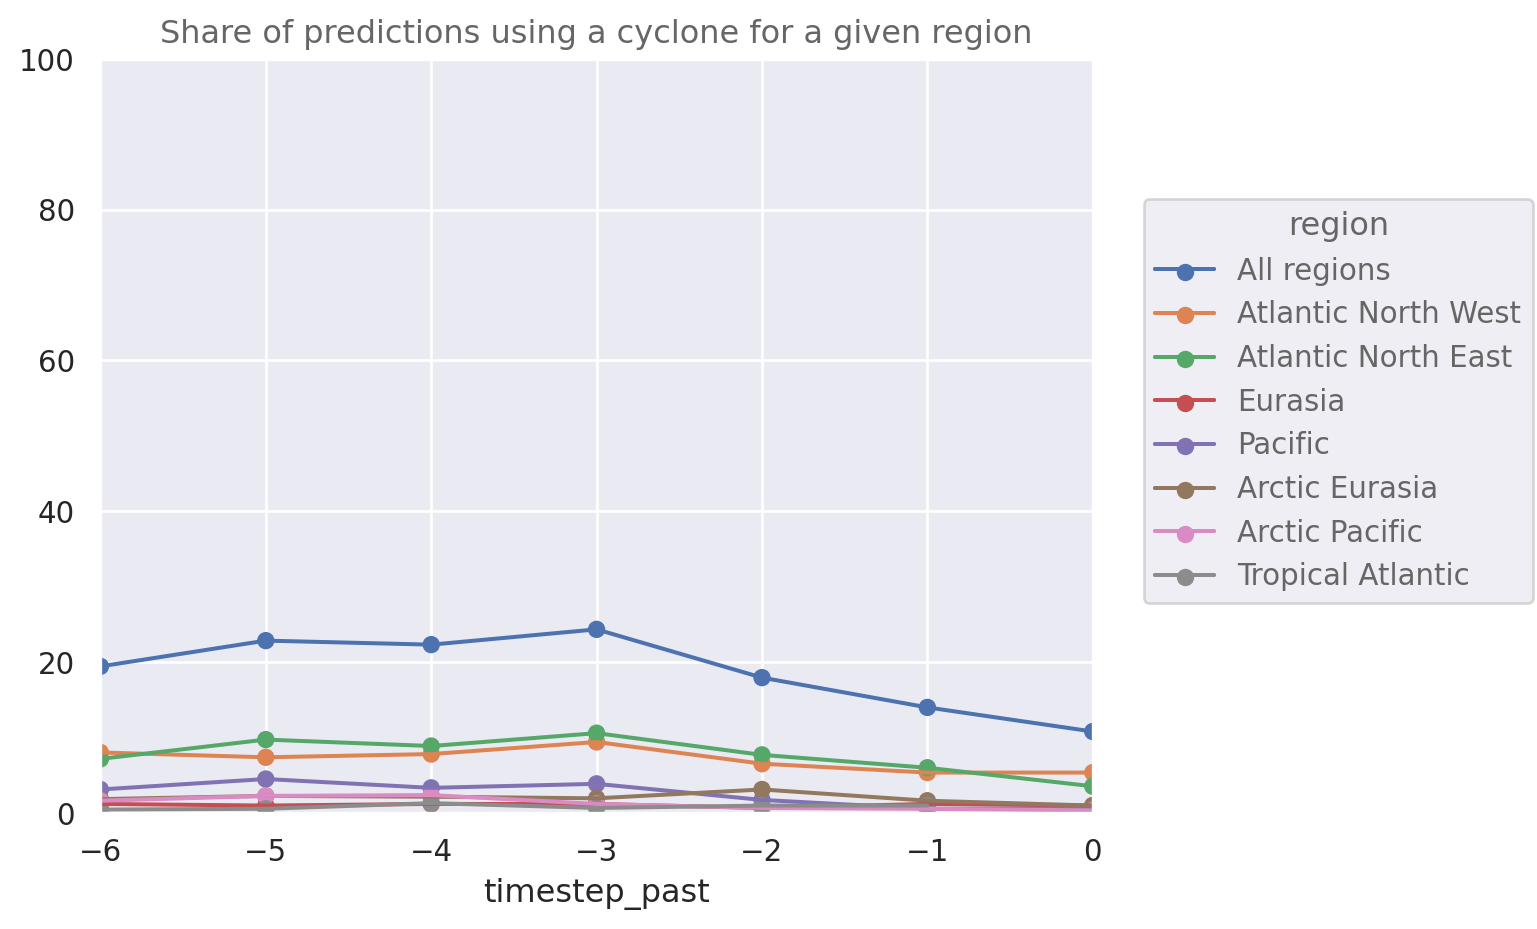

In [601]:
df_counts = df_blob_cycs.reset_index().query("category=='large neutral'").groupby(['time_of_event','timestep_past','region']).msl.count().reset_index()
df_all_counts = df_blob_cycs.reset_index().query("category=='large neutral'").groupby(['time_of_event','timestep_past']).msl.count().reset_index()
df_all_counts['region'] = 'All regions'
df_counts = pd.concat([df_counts, df_all_counts])

(so.Plot(df_counts, x='timestep_past', color='region')
 .add(so.Line(), so.Count(), so.Norm(func=lambda x:937, percent=True))
 .add(so.Line(), so.Count(),data=df_all_counts)
 .add(so.Dot(), so.Count(), so.Norm(func=lambda x:937, percent=True))
#  .facet(col='category')
 .scale(color=so.Nominal(order=['All regions','Atlantic North West','Atlantic North East',
       'Eurasia', 'Pacific', 'Arctic Eurasia','Arctic Pacific', 
       'Tropical Atlantic']))

 .layout(size=(6,5))
 .limit(x=(-6,0), y=(0,100))
 .label(title='Share of predictions using a cyclone for a given region', )
 )



In [421]:
df_blob_cycs.groupby('region').category.count()/df_blob_cycs.groupby('region').msl.count()

region
Arctic Eurasia         0.040772
Arctic Pacific         0.016648
Atlantic North East    0.102129
Atlantic North West    0.071365
Eurasia                0.028882
Pacific                0.021775
Tropical Atlantic      0.034451
dtype: float64

In [163]:
df_.rename(columns=dict(cyclones='track_id')).set_index(['track_id','date']).reset_index().groupby(['track_id','date']).attributions.count().value_counts()

attributions
1    10390
2     3168
3      893
4      291
5       67
6       10
7        2
Name: count, dtype: int64

## Number of blobs per prediction

<Axes: xlabel='geometry', ylabel='timestep_past'>

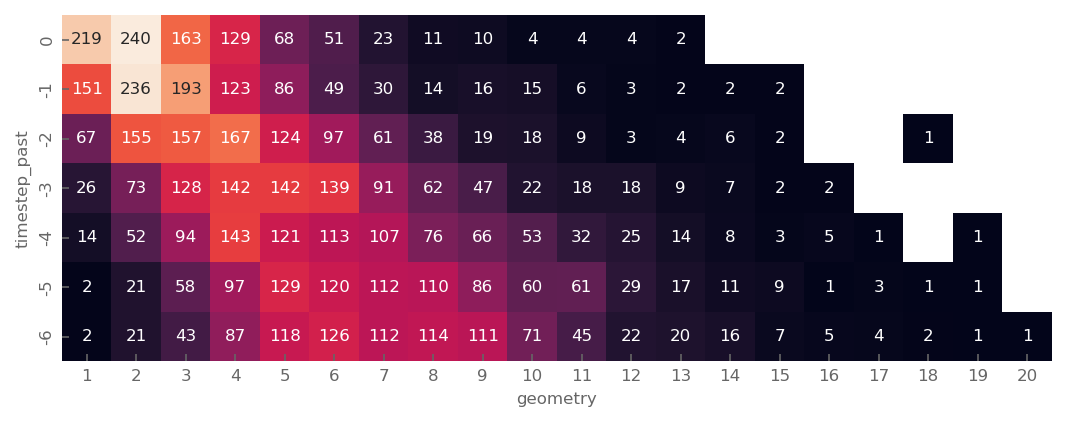

In [536]:
fig, axs = plt.subplots(figsize=(10,3))
sns.heatmap(df_.groupby(['timestep_past','time_of_event']).geometry.count().reset_index().groupby('timestep_past').geometry.value_counts().unstack().iloc[::-1], square=True, annot=True, cbar=False, fmt='.0f')

## Number of blobs per prediction without small ones

<Axes: xlabel='geometry', ylabel='timestep_past'>

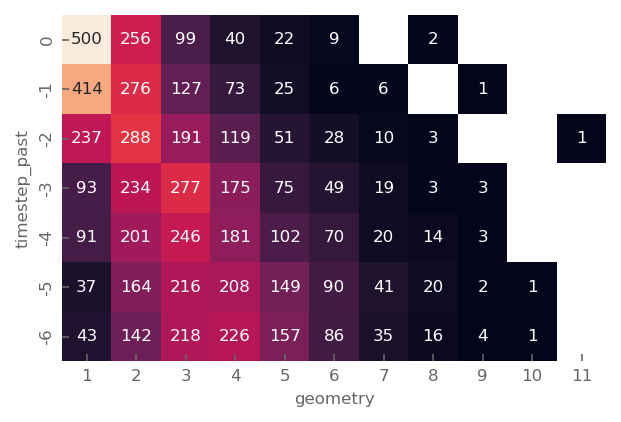

In [540]:
fig, axs = plt.subplots(figsize=(10,3))
sns.heatmap(df_.loc[np.abs(df_.segment_size)>5e5].groupby(['timestep_past','time_of_event']).geometry.count().reset_index().groupby('timestep_past').geometry.value_counts().unstack().iloc[::-1], square=True, annot=True, cbar=False, fmt='.0f')